In [1]:
import os
import glob
import random
import numpy as np
import mne
import matplotlib.pyplot as plt

from scipy.signal import welch
from scipy.stats import entropy

DATA_DIR = "./data/ds004148"

subjects = sorted(glob.glob(os.path.join(DATA_DIR, "sub-*")))

rest_files = {}
task_files = {}

for subj_path in subjects:
    subj = os.path.basename(subj_path)
    eeg_path = os.path.join(subj_path, "ses-session1", "eeg")

    # Rest: eyesclosed and eyesopen
    rest_closed = glob.glob(os.path.join(eeg_path, "*task-eyesclosed*_eeg.vhdr"))
    rest_open = glob.glob(os.path.join(eeg_path, "*task-eyesopen*_eeg.vhdr"))
    rest = rest_closed + rest_open

    # Task: everything that's NOT eyesclosed, eyesopen, OR music
    all_task = glob.glob(os.path.join(eeg_path, "*task-*_eeg.vhdr"))
    task = [t for t in all_task
            if "task-eyesclosed" not in t
            and "task-eyesopen" not in t
            # and "task-music" not in t
            ]  # Exclude music files

    if len(rest) > 0:
        rest_files[subj] = rest
    if len(task) > 0:
        task_files[subj] = task

subjects = sorted(rest_files.keys())
subjects

['sub-13',
 'sub-14',
 'sub-15',
 'sub-22',
 'sub-23',
 'sub-24',
 'sub-25',
 'sub-40',
 'sub-47',
 'sub-49']

In [2]:
def load_signal_all_channels(file):
    try:
        raw = mne.io.read_raw_brainvision(file, preload=True, verbose=False)

        if raw.info["bads"]:
            raw.drop_channels(raw.info["bads"])

        raw.notch_filter(50, verbose=False)
        raw.filter(1, 40, verbose=False)
        raw.resample(TARGET_SFREQ)

        data = raw.get_data()

        if not np.all(np.isfinite(data)):
            return None, None

        if np.any(np.std(data, axis=1) < 1e-10):
            return None, None

        return data, raw.ch_names
    except:
        return None, None

# ============================================================
# FEATURE FUNCTIONS (UNCHANGED)
# ============================================================

def hjorth_activity(x): return np.var(x)

def hjorth_mobility(x):
    if len(x) < 2: return np.nan
    v = np.var(x)
    if v == 0: return np.nan
    return np.sqrt(np.var(np.diff(x)) / v)

def hjorth_complexity(x):
    m = hjorth_mobility(x)
    if np.isnan(m) or m == 0: return np.nan
    return hjorth_mobility(np.diff(x)) / m

def spectral_entropy(psd):
    psd = np.nan_to_num(psd)
    p = psd / (np.sum(psd) + 1e-12)
    return entropy(p)

def spectral_complexity(psd):
    psd = np.nan_to_num(psd)
    p = psd / (np.sum(psd) + 1e-12)
    uniform = np.ones_like(p) / len(p)
    return entropy(p, uniform)

def extract_features_window(data, ch_names):
    feats = {}
    n_channels = len(ch_names)

    for i, ch in enumerate(ch_names):
        x = data[i]

        freqs, psd = welch(
            x,
            fs=TARGET_SFREQ,
            nperseg=WINDOW_LEN,
            noverlap=0
        )

        if "hjorth" in FEATURE_SET:
            a = hjorth_activity(x)
            m = hjorth_mobility(x)
            c = hjorth_complexity(x)

            feats[f"{ch}_a"] = a
            feats[f"{ch}_m"] = m
            feats[f"{ch}_c"] = c

            feats[f"{ch}_log_a"] = np.log(a)
            feats[f"{ch}_log_m"] = np.log(m)
            feats[f"{ch}_log_c"] = np.log(c)

        if "spectral" in FEATURE_SET:
            feats[f"{ch}_se"] = spectral_entropy(psd)

        if "bandpower" in FEATURE_SET:
            total = 0
            bp = {}

            for b, (low, high) in bands.items():
                mask = (freqs >= low) & (freqs < high)
                val = np.trapezoid(psd[mask], freqs[mask]) if np.any(mask) else 0
                bp[b] = val
                total += val

            for b in bp:
                feats[f"{ch}_{b}"] = bp[b] / total if total > 0 else np.nan

    if "coherence" in FEATURE_SET:
        max_ch = min(8, n_channels)

        for i, j in combinations(range(max_ch), 2):
            freqs, coh = coherence(
                data[i], data[j],
                fs=TARGET_SFREQ,
                nperseg=WINDOW_LEN,
                noverlap=0
            )
            feats[f"coh_{i}_{j}"] = np.mean(coh)

    return feats

In [3]:
def compute_covariance(w):
    # shrinkage covariance for stability
    return LedoitWolf().fit(w.T).covariance_

def whiten(C, C_ref):
    C_ref_inv_sqrt = fractional_matrix_power(C_ref, -0.5)
    return C_ref_inv_sqrt @ C @ C_ref_inv_sqrt

In [8]:
import numpy as np
import mne

from scipy.signal import welch, coherence
from scipy.stats import entropy
from itertools import combinations
from scipy.linalg import fractional_matrix_power

from sklearn.metrics import classification_report, roc_auc_score
from sklearn.covariance import LedoitWolf

from xgboost import XGBClassifier

from pyriemann.utils.mean import mean_covariance
from pyriemann.tangentspace import TangentSpace
from sklearn.preprocessing import StandardScaler

# ============================================================
# CONFIG
# ============================================================

TARGET_SFREQ = 125
WINDOW_SEC = 2.0
WINDOW_LEN = int(WINDOW_SEC * TARGET_SFREQ)

bands = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 45),
}

FEATURE_SET = ["hjorth",
               # "spectral",
               "bandpower",
               # "coherence"
               ]

all_feats = []
all_covs = []
all_labels = []
all_subjects = []

valid_subjects = sorted(set(rest_files.keys()) & set(task_files.keys()))

for subj in valid_subjects:

    for label, file_list in [(0, rest_files[subj]), (1, task_files[subj])]:

        for f in file_list:
            data, ch_names = load_signal_all_channels(f)
            if data is None:
                continue

            for i in range(data.shape[1] // WINDOW_LEN):
                w = data[:, i*WINDOW_LEN:(i+1)*WINDOW_LEN]

                if np.any(np.std(w, axis=1) < 1e-10):
                    continue

                # handcrafted features
                feats = extract_features_window(w, ch_names)
                vals = np.array(list(feats.values()))
                if not np.all(np.isfinite(vals)):
                    continue

                # covariance
                C = compute_covariance(w)

                all_feats.append(vals)
                all_covs.append(C)
                all_labels.append(label)
                all_subjects.append(subj)

X_feats = np.array(all_feats)
covs = np.array(all_covs)
y = np.array(all_labels)
subjects = np.array(all_subjects)

# ============================================================
# SUBJECT SPLIT
# ============================================================

unique_subjects = np.unique(subjects)
np.random.seed(42)

train_subjects = np.random.choice(unique_subjects, int(0.7*len(unique_subjects)), replace=False)
test_subjects = np.array([s for s in unique_subjects if s not in train_subjects])

train_mask = np.isin(subjects, train_subjects)
test_mask = np.isin(subjects, test_subjects)

# ============================================================
# ITSA (LEAKAGE FIXED)
# ============================================================

covs_train = covs[train_mask]
covs_test  = covs[test_mask]

# ---- compute global reference from TRAIN only ----
global_ref = mean_covariance(covs_train, metric='riemann')

covs_white_train = np.array([
    whiten(C, global_ref) for C in covs_train
])

covs_white_test = np.array([
    whiten(C, global_ref) for C in covs_test
])

# ---- tangent space projection ----
ts = TangentSpace(metric='riemann')
ts.fit(covs_white_train)

X_ts_train = ts.transform(covs_white_train)
X_ts_test  = ts.transform(covs_white_test)

scaler = StandardScaler()
X_feats_train = scaler.fit_transform(X_feats[train_mask])
X_feats_test  = scaler.transform(X_feats[test_mask])

# ---- concatenate features ----
X_train = np.concatenate([X_feats_train, X_ts_train], axis=1)
X_test  = np.concatenate([X_feats_test,  X_ts_test], axis=1)

y_train = y[train_mask]
y_test  = y[test_mask]

model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.60      0.37      0.46       900
           1       0.67      0.84      0.74      1350

    accuracy                           0.65      2250
   macro avg       0.63      0.60      0.60      2250
weighted avg       0.64      0.65      0.63      2250

ROC-AUC: 0.6865679012345678


In [10]:
import signal
import matplotlib.pyplot as plt
import numpy as np

# Find the first valid window from any subject
first_window_plotted = False

for subj in valid_subjects:
    if first_window_plotted:
        break

    for label, file_list in [(0, rest_files[subj]), (1, task_files[subj])]:
        if first_window_plotted:
            break

        for f in file_list:
            data, ch_names = load_signal_all_channels(f)
            if data is None:
                continue

            # Take the first window from this file
            i = 0
            w = data[:, i*WINDOW_LEN:(i+1)*WINDOW_LEN]

            if not np.any(np.std(w, axis=1) < 1e-10):
                # Found a valid window - plot it
                fs = 125  # Your sampling rate

                plt.figure(figsize=(14, 10))

                # Plot power spectrum for all channels
                n_channels = min(w.shape[0], 16)
                n_rows = int(np.ceil(n_channels / 4))

                for ch_idx in range(n_channels):
                    plt.subplot(n_rows, 4, ch_idx + 1)
                    freqs, psd = signal.welch(w[ch_idx, :], fs=fs,
                                              nperseg=min(128, w.shape[1]))
                    plt.semilogy(freqs, psd, linewidth=1.5)
                    plt.title(ch_names[ch_idx], fontsize=8)
                    plt.xlabel('Frequency (Hz)', fontsize=8)
                    plt.ylabel('Power Spectral Density', fontsize=8)
                    plt.grid(True, alpha=0.3)
                    plt.xlim(0, fs/2)

                plt.suptitle(f'Power Spectra - Subject {subj}, {"Rest" if label==0 else "Task"}',
                           fontsize=14)
                plt.tight_layout()
                plt.savefig('power_spectrum.png')

                first_window_plotted = True
                break

# testing

In [9]:
# ============================================================
# DISTRIBUTION MATCHING (RESCALING)
# ============================================================

def rescale_features(X):
    norms = np.linalg.norm(X, axis=1)
    mean_norm = np.mean(norms) + 1e-12
    return X / mean_norm

# apply to tangent features ONLY (not handcrafted)
X_ts_train = rescale_features(X_ts_train)
X_ts_test  = rescale_features(X_ts_test)

In [10]:
# ============================================================
# CALIBRATION SPLIT (FROM TEST SET)
# ============================================================

np.random.seed(42)

test_idx = np.arange(len(X_ts_test))
np.random.shuffle(test_idx)

calib_size = int(0.3 * len(test_idx))  # 30% calibration

calib_idx = test_idx[:calib_size]
eval_idx  = test_idx[calib_size:]

X_calib = X_ts_test[calib_idx]
y_calib = y_test[calib_idx]

X_eval = X_ts_test[eval_idx]
y_eval = y_test[eval_idx]

In [11]:
# ============================================================
# CLASS ANCHORS
# ============================================================

def compute_class_means(X, y):
    classes = np.unique(y)
    means = []
    for c in classes:
        means.append(np.mean(X[y == c], axis=0))
    return np.stack(means), classes

C_train_means, classes = compute_class_means(X_ts_train, y_train)
C_calib_means, _       = compute_class_means(X_calib, y_calib)

In [14]:
# ============================================================
# ROTATIONAL ALIGNMENT
# ============================================================

# cross-covariance
CtC = C_train_means.T @ C_calib_means

# SVD
U, S, Vt = np.linalg.svd(CtC)

# retain 99.9% variance
var_explained = np.cumsum(S) / np.sum(S)
k = np.searchsorted(var_explained, 0.999) + 1

U_tilde = U[:, :k]
V_tilde = Vt.T[:, :k]

# rotation matrix
R = U_tilde @ V_tilde.T

In [15]:
# ============================================================
# APPLY ROTATION
# ============================================================

X_eval_rot = (R @ X_eval.T).T

In [16]:
# ============================================================
# FINAL FEATURES
# ============================================================

# handcrafted features (already scaled earlier)
X_feats_train = scaler.fit_transform(X_feats[train_mask])
X_feats_test  = scaler.transform(X_feats[test_mask])

# split handcrafted same way
X_feats_eval = X_feats_test[eval_idx]

# final matrices
X_train_final = np.concatenate([X_feats_train, X_ts_train], axis=1)
X_test_final  = np.concatenate([X_feats_eval, X_eval_rot], axis=1)

y_train_final = y_train
y_test_final  = y_eval

In [17]:
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier

from pyriemann.utils.mean import mean_covariance
from pyriemann.tangentspace import TangentSpace

# ============================================================
# ITSA (GLOBAL ALIGNMENT, NO LEAKAGE)
# ============================================================

covs_train = covs[train_mask]
covs_test  = covs[test_mask]

y_train = y[train_mask]
y_test  = y[test_mask]

# ---- global reference (TRAIN ONLY) ----
global_ref = mean_covariance(covs_train, metric='riemann')

def whiten(C, C_ref):
    C_ref_inv_sqrt = fractional_matrix_power(C_ref, -0.5)
    return C_ref_inv_sqrt @ C @ C_ref_inv_sqrt

covs_white_train = np.array([whiten(C, global_ref) for C in covs_train])
covs_white_test  = np.array([whiten(C, global_ref) for C in covs_test])

# ---- tangent space ----
ts = TangentSpace(metric='riemann')
ts.fit(covs_white_train)

X_ts_train = ts.transform(covs_white_train)
X_ts_test  = ts.transform(covs_white_test)

# ============================================================
# DISTRIBUTION MATCHING (RESCALING)
# ============================================================

def rescale_features(X):
    norms = np.linalg.norm(X, axis=1)
    return X / (np.mean(norms) + 1e-12)

X_ts_train = rescale_features(X_ts_train)
X_ts_test  = rescale_features(X_ts_test)

# ============================================================
# CALIBRATION SPLIT (TEST SET)
# ============================================================

np.random.seed(42)

idx = np.arange(len(X_ts_test))
np.random.shuffle(idx)

calib_size = int(0.3 * len(idx))

calib_idx = idx[:calib_size]
eval_idx  = idx[calib_size:]

X_calib = X_ts_test[calib_idx]
y_calib = y_test[calib_idx]

X_eval = X_ts_test[eval_idx]
y_eval = y_test[eval_idx]

# ============================================================
# CLASS ANCHORS (BINARY)
# ============================================================

def class_means(X, y):
    return np.array([
        X[y == 0].mean(axis=0),
        X[y == 1].mean(axis=0)
    ])

C_train_means = class_means(X_ts_train, y_train)
C_calib_means = class_means(X_calib, y_calib)

# ============================================================
# ROTATIONAL ALIGNMENT (BINARY-STABLE)
# ============================================================

# difference vectors
d_train = C_train_means[1] - C_train_means[0]
d_calib = C_calib_means[1] - C_calib_means[0]

# normalize
d_train /= np.linalg.norm(d_train) + 1e-12
d_calib /= np.linalg.norm(d_calib) + 1e-12

# rotation matrix (rank-1 alignment)
R = np.outer(d_train, d_calib)

# apply rotation to evaluation set
X_eval_rot = (R @ X_eval.T).T

# ============================================================
# HANDCRAFTED FEATURES (SCALED)
# ============================================================

scaler = StandardScaler()

X_feats_train = scaler.fit_transform(X_feats[train_mask])
X_feats_test  = scaler.transform(X_feats[test_mask])

X_feats_eval = X_feats_test[eval_idx]

# ============================================================
# FINAL DATA
# ============================================================

X_train_final = np.concatenate([X_feats_train, X_ts_train], axis=1)
X_test_final  = np.concatenate([X_feats_eval, X_eval_rot], axis=1)

y_train_final = y_train
y_test_final  = y_eval

# ============================================================
# MODEL
# ============================================================

model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42
)

model.fit(X_train_final, y_train_final)

y_pred = model.predict(X_test_final)
y_proba = model.predict_proba(X_test_final)[:, 1]

print(classification_report(y_test_final, y_pred))
print("ROC-AUC:", roc_auc_score(y_test_final, y_proba))

              precision    recall  f1-score   support

           0       0.69      0.69      0.69       642
           1       0.79      0.78      0.78       933

    accuracy                           0.74      1575
   macro avg       0.74      0.74      0.74      1575
weighted avg       0.75      0.74      0.74      1575

ROC-AUC: 0.7711749523361148


# a better implementation, close to the paper

In [20]:
import os
import glob
import random
import numpy as np
import mne
import matplotlib.pyplot as plt

from scipy.signal import welch
from scipy.stats import entropy

DATA_DIR = "./data/ds004148"

subjects = sorted(glob.glob(os.path.join(DATA_DIR, "sub-*")))

rest_files = {}
task_files = {}

for subj_path in subjects:
    subj = os.path.basename(subj_path)
    eeg_path = os.path.join(subj_path, "ses-session1", "eeg")

    # Rest: eyesclosed and eyesopen
    rest_closed = glob.glob(os.path.join(eeg_path, "*task-eyesclosed*_eeg.vhdr"))
    rest_open = glob.glob(os.path.join(eeg_path, "*task-eyesopen*_eeg.vhdr"))
    rest = rest_closed + rest_open

    # Task: everything that's NOT eyesclosed, eyesopen, OR music
    all_task = glob.glob(os.path.join(eeg_path, "*task-*_eeg.vhdr"))
    task = [t for t in all_task
            if "task-eyesclosed" not in t
            and "task-eyesopen" not in t
            # and "task-music" not in t
            ]  # Exclude music files

    if len(rest) > 0:
        rest_files[subj] = rest
    if len(task) > 0:
        task_files[subj] = task

subjects = sorted(rest_files.keys())
subjects

['sub-13',
 'sub-14',
 'sub-15',
 'sub-22',
 'sub-23',
 'sub-24',
 'sub-25',
 'sub-40',
 'sub-47',
 'sub-49']

In [21]:
def load_signal_all_channels(file):
    try:
        raw = mne.io.read_raw_brainvision(file, preload=True, verbose=False)

        if raw.info["bads"]:
            raw.drop_channels(raw.info["bads"])

        raw.notch_filter(50, verbose=False)
        raw.filter(1, 40, verbose=False)
        raw.resample(TARGET_SFREQ)

        data = raw.get_data()

        if not np.all(np.isfinite(data)):
            return None, None

        if np.any(np.std(data, axis=1) < 1e-10):
            return None, None

        return data, raw.ch_names
    except:
        return None, None

# ============================================================
# FEATURE FUNCTIONS (UNCHANGED)
# ============================================================

def hjorth_activity(x): return np.var(x)

def hjorth_mobility(x):
    if len(x) < 2: return np.nan
    v = np.var(x)
    if v == 0: return np.nan
    return np.sqrt(np.var(np.diff(x)) / v)

def hjorth_complexity(x):
    m = hjorth_mobility(x)
    if np.isnan(m) or m == 0: return np.nan
    return hjorth_mobility(np.diff(x)) / m

def spectral_entropy(psd):
    psd = np.nan_to_num(psd)
    p = psd / (np.sum(psd) + 1e-12)
    return entropy(p)

def spectral_complexity(psd):
    psd = np.nan_to_num(psd)
    p = psd / (np.sum(psd) + 1e-12)
    uniform = np.ones_like(p) / len(p)
    return entropy(p, uniform)

def extract_features_window(data, ch_names):
    feats = {}
    n_channels = len(ch_names)

    for i, ch in enumerate(ch_names):
        x = data[i]

        freqs, psd = welch(
            x,
            fs=TARGET_SFREQ,
            nperseg=WINDOW_LEN,
            noverlap=0
        )

        if "hjorth" in FEATURE_SET:
            a = hjorth_activity(x)
            m = hjorth_mobility(x)
            c = hjorth_complexity(x)

            feats[f"{ch}_a"] = a
            feats[f"{ch}_m"] = m
            feats[f"{ch}_c"] = c

            feats[f"{ch}_log_a"] = np.log(a)
            feats[f"{ch}_log_m"] = np.log(m)
            feats[f"{ch}_log_c"] = np.log(c)

        if "spectral" in FEATURE_SET:
            feats[f"{ch}_se"] = spectral_entropy(psd)

        if "bandpower" in FEATURE_SET:
            total = 0
            bp = {}

            for b, (low, high) in bands.items():
                mask = (freqs >= low) & (freqs < high)
                val = np.trapezoid(psd[mask], freqs[mask]) if np.any(mask) else 0
                bp[b] = val
                total += val

            for b in bp:
                feats[f"{ch}_{b}"] = bp[b] / total if total > 0 else np.nan

    if "coherence" in FEATURE_SET:
        max_ch = min(8, n_channels)

        for i, j in combinations(range(max_ch), 2):
            freqs, coh = coherence(
                data[i], data[j],
                fs=TARGET_SFREQ,
                nperseg=WINDOW_LEN,
                noverlap=0
            )
            feats[f"coh_{i}_{j}"] = np.mean(coh)

    return feats

def compute_covariance(w):
    # shrinkage covariance for stability
    return LedoitWolf().fit(w.T).covariance_

def whiten(C, C_ref):
    C_ref_inv_sqrt = fractional_matrix_power(C_ref, -0.5)
    return C_ref_inv_sqrt @ C @ C_ref_inv_sqrt

In [19]:
import numpy as np
from scipy.linalg import logm, fractional_matrix_power
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

# ============================================================
# HELPERS
# ============================================================

def log_euclidean_mean(covs):
    logs = np.array([logm(C) for C in covs])
    return np.mean(logs, axis=0)

# def recenter_and_project(covs, M):
#     M_inv_sqrt = fractional_matrix_power(M, -0.5)
#     out = []
#     for C in covs:
#         C_rec = M_inv_sqrt @ C @ M_inv_sqrt
#         C_ts = logm(C_rec)
#         out.append(C_ts)
#     return np.array(out)

def recenter_and_project(covs, M):
    M_inv_sqrt = fractional_matrix_power(M, -0.5)
    out = []
    for C in covs:
        C_rec = M_inv_sqrt @ C @ M_inv_sqrt
        C_ts = logm(C_rec)

        # enforce real + symmetric
        C_ts = np.real(C_ts)
        C_ts = (C_ts + C_ts.T) / 2

        out.append(C_ts)
    return np.array(out)

def frob_rescale(X):
    norms = np.array([np.linalg.norm(x, 'fro') for x in X])
    mean_norm = np.mean(norms) + 1e-12
    return X / mean_norm

def flatten(X):
    return X.reshape(len(X), -1)

def class_means(X, y):
    classes = np.unique(y)
    means = []
    for c in classes:
        means.append(np.mean(X[y == c], axis=0))
    return np.stack(means), classes

# ============================================================
# LOSO LOOP
# ============================================================

subjects_unique = np.unique(subjects)
all_preds = []
all_probs = []
all_true = []

for test_subj in subjects_unique:

    train_mask = subjects != test_subj
    test_mask  = subjects == test_subj

    covs_train = covs[train_mask]
    covs_test  = covs[test_mask]

    y_train = y[train_mask]
    y_test  = y[test_mask]

    # ========================================================
    # STEP 1: RECENTERING (LOG-EUCLIDEAN)
    # ========================================================

    M = log_euclidean_mean(covs_train)

    C_ts_train = recenter_and_project(covs_train, M)
    C_ts_test  = recenter_and_project(covs_test, M)

    # ========================================================
    # STEP 2: RESCALE
    # ========================================================

    # split test into calibration / evaluation
    idx = np.arange(len(C_ts_test))
    np.random.shuffle(idx)

    calib_size = int(0.3 * len(idx))
    calib_idx = idx[:calib_size]
    eval_idx  = idx[calib_size:]

    C_calib = C_ts_test[calib_idx]
    C_eval  = C_ts_test[eval_idx]

    y_calib = y_test[calib_idx]
    y_eval  = y_test[eval_idx]

    # rescale each set independently
    C_train_sc = frob_rescale(C_ts_train)
    C_calib_sc = frob_rescale(C_calib)
    C_eval_sc  = frob_rescale(C_eval)

    # ========================================================
    # STEP 3: ROTATION
    # ========================================================

    # flatten for rotation
    X_train_flat = flatten(C_train_sc)
    X_calib_flat = flatten(C_calib_sc)
    X_eval_flat  = flatten(C_eval_sc)

    # anchors
    C_train_means, classes = class_means(X_train_flat, y_train)
    C_calib_means, _       = class_means(X_calib_flat, y_calib)

    # cross-product (FEATURE space)
    CtC = C_train_means.T @ C_calib_means

    # SVD
    U, S, Vt = np.linalg.svd(CtC)

    # truncate 99.9%
    var_exp = np.cumsum(S) / (np.sum(S) + 1e-12)
    k = np.searchsorted(var_exp, 0.999) + 1

    U_tilde = U[:, :k]
    V_tilde = Vt.T[:, :k]

    R = U_tilde @ V_tilde.T

    # rotate evaluation set only
    X_eval_rot = (R @ X_eval_flat.T).T

    # ========================================================
    # TRAIN / TEST
    # ========================================================

    model = XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        n_jobs=-1,
        random_state=42
    )

    model.fit(X_train_flat, y_train)

    y_pred = model.predict(X_eval_rot)
    y_prob = model.predict_proba(X_eval_rot)[:, 1]

    all_preds.append(y_pred)
    all_probs.append(y_prob)
    all_true.append(y_eval)

# ============================================================
# FINAL METRICS
# ============================================================

y_true = np.concatenate(all_true)
y_pred = np.concatenate(all_preds)
y_prob = np.concatenate(all_probs)

from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))
print("ROC-AUC:", roc_auc_score(y_true, y_prob))

              precision    recall  f1-score   support

           0       0.06      0.00      0.00      2091
           1       0.60      0.99      0.75      3159

    accuracy                           0.60      5250
   macro avg       0.33      0.50      0.37      5250
weighted avg       0.38      0.60      0.45      5250

ROC-AUC: 0.3692764283656467


# not close to paper fixed

In [15]:
import numpy as np
import mne
from scipy.linalg import fractional_matrix_power
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
from pyriemann.utils.mean import mean_covariance
from pyriemann.tangentspace import TangentSpace
from xgboost import XGBClassifier

# ============================================================
# CONFIG
# ============================================================

TARGET_SFREQ = 125
WINDOW_SEC = 2.0
WINDOW_LEN = int(WINDOW_SEC * TARGET_SFREQ)
REG = 1e-5
MAX_WINDOWS_PER_FILE = 50

# ============================================================
# FEATURES
# ============================================================

def compute_covariance(w):
    w = w - np.mean(w, axis=1, keepdims=True)
    C = (w @ w.T) / (w.shape[1] - 1)
    C += REG * np.eye(C.shape[0])
    return C


def hjorth_activity(x):
    return np.var(x)


def hjorth_mobility(x):
    v = np.var(x)
    return np.sqrt(np.var(np.diff(x)) / (v + 1e-12))


def hjorth_complexity(x):
    m = hjorth_mobility(x)
    return hjorth_mobility(np.diff(x)) / (m + 1e-12)


def extract_features_window(w, ch_names):
    feats = []
    for i in range(w.shape[0]):
        x = w[i]

        feats.extend([
            hjorth_activity(x),
            hjorth_mobility(x),
            hjorth_complexity(x),
            np.log(hjorth_activity(x) + 1e-12),
            np.log(hjorth_mobility(x) + 1e-12),
        ])
    return np.array(feats)

# ============================================================
# SIGNAL LOADING
# ============================================================

def load_signal_all_channels(file):
    raw = mne.io.read_raw_brainvision(file, preload=True, verbose=False)

    if raw.info["bads"]:
        raw.drop_channels(raw.info["bads"])

    raw.notch_filter(50, verbose=False)
    raw.filter(1, 40, verbose=False)
    raw.resample(TARGET_SFREQ)

    data = raw.get_data()
    if not np.all(np.isfinite(data)):
        return None, None

    return data, raw.ch_names

In [16]:
def extract_windows(file, label, subject):
    data, ch_names = load_signal_all_channels(file)
    if data is None:
        return [], [], [], []

    X_feats, covs, y, subs = [], [], [], []

    n_windows = min(data.shape[1] // WINDOW_LEN, MAX_WINDOWS_PER_FILE)

    for i in range(n_windows):
        w = data[:, i * WINDOW_LEN:(i + 1) * WINDOW_LEN]

        # reject flat windows
        if np.any(np.std(w, axis=1) < 1e-10):
            continue

        f = extract_features_window(w, ch_names)
        C = compute_covariance(w)

        if not np.all(np.isfinite(f)):
            continue

        X_feats.append(f)
        covs.append(C)
        y.append(label)
        subs.append(subject)

    return X_feats, covs, y, subs



# ============================================================
# BUILD DATASET (FULL ALIGNMENT GUARANTEE)
# ============================================================

def build_dataset(rest_files, task_files, subjects):
    X_feats, covs, y, subs = [], [], [], []

    for subj in subjects:

        for label, file_dict in [(0, rest_files), (1, task_files)]:

            if subj not in file_dict:
                continue

            for f in file_dict[subj]:

                xf, cv, yl, sl = extract_windows(f, label, subj)

                X_feats.extend(xf)
                covs.extend(cv)
                y.extend(yl)
                subs.extend(sl)

    return (
        np.array(X_feats),
        np.array(covs),
        np.array(y),
        np.array(subs)
    )

# ============================================================
# SUBJECT SPLIT
# ============================================================

def split_subjects(subjects, test_ratio=0.3, seed=42):
    subjects = np.array(subjects)
    rng = np.random.RandomState(seed)
    rng.shuffle(subjects)

    n_test = int(len(subjects) * test_ratio)
    return subjects[n_test:], subjects[:n_test]

# ============================================================
# PIPELINE
# ============================================================


In [18]:
train_subjects, test_subjects = split_subjects(valid_subjects)
train_subjects, test_subjects

(array(['sub-13', 'sub-40', 'sub-15', 'sub-49', 'sub-23', 'sub-22',
        'sub-25'], dtype='<U6'),
 array(['sub-47', 'sub-14', 'sub-24'], dtype='<U6'))

In [19]:
X_feats, covs, y, subjects_arr = build_dataset(
    rest_files,
    task_files,
    valid_subjects
)

In [20]:
X_feats.shape

(2500, 305)

In [21]:
covs.shape

(2500, 61, 61)

In [22]:
y.shape

(2500,)

In [23]:
subjects_arr

array(['sub-13', 'sub-13', 'sub-13', ..., 'sub-49', 'sub-49', 'sub-49'],
      shape=(2500,), dtype='<U6')

In [24]:
train_mask = np.isin(subjects_arr, train_subjects)
test_mask  = np.isin(subjects_arr, test_subjects)

X_feats_train = X_feats[train_mask]
X_feats_test  = X_feats[test_mask]

covs_train = covs[train_mask]
covs_test  = covs[test_mask]

y_train = y[train_mask]
y_test  = y[test_mask]

In [26]:
X_feats_test.shape

(750, 305)

In [25]:
X_feats_train.shape

(1750, 305)

In [27]:
def whiten(C):
    M_inv_sqrt = fractional_matrix_power(M, -0.5)
    return M_inv_sqrt @ C @ M_inv_sqrt

In [28]:
M = mean_covariance(covs_train, metric='riemann')

covs_train_w = np.array([whiten(C) for C in covs_train])
covs_test_w  = np.array([whiten(C) for C in covs_test])

ts = TangentSpace(metric='riemann')
ts.fit(covs_train_w)

X_ts_train = ts.transform(covs_train_w)
X_ts_test  = ts.transform(covs_test_w)

In [29]:
scaler = StandardScaler()
X_feats_train = scaler.fit_transform(X_feats_train)
X_feats_test  = scaler.transform(X_feats_test)

X_train = np.concatenate([X_feats_train, X_ts_train], axis=1)
X_test  = np.concatenate([X_feats_test, X_ts_test], axis=1)


model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.41      0.26      0.32       300
           1       0.60      0.75      0.67       450

    accuracy                           0.56       750
   macro avg       0.51      0.51      0.49       750
weighted avg       0.53      0.56      0.53       750

ROC-AUC: 0.5336000000000001


# not close to paper fix attempt (good one, 0.77 roc-auc, without ledoit actually)

## config

In [7]:
import numpy as np
import mne

from scipy.signal import welch
from scipy.stats import entropy
from itertools import combinations

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.covariance import LedoitWolf

from xgboost import XGBClassifier

from pyriemann.utils.mean import mean_covariance
from pyriemann.tangentspace import TangentSpace
from scipy.linalg import fractional_matrix_power


TARGET_SFREQ = 125
WINDOW_SEC = 2.0
WINDOW_LEN = int(WINDOW_SEC * TARGET_SFREQ)

REG = 1e-5

## proper covariance, not ledoit yet

In [2]:
def compute_covariance(w):
    w = w - np.mean(w, axis=1, keepdims=True)

    s = w.shape[1]
    C = (w @ w.T) / (s - 1)

    # small ridge regularization (NOT full Ledoit collapse)
    C += REG * np.eye(C.shape[0])

    return C

## load signal

In [3]:
def load_signal_all_channels(file):
    try:
        raw = mne.io.read_raw_brainvision(file, preload=True, verbose=False)

        if raw.info["bads"]:
            raw.drop_channels(raw.info["bads"])

        raw.notch_filter(50, verbose=False)
        raw.filter(1, 40, verbose=False)
        raw.resample(TARGET_SFREQ)

        data = raw.get_data()

        if not np.all(np.isfinite(data)):
            return None, None

        return data, raw.ch_names

    except:
        return None, None

## features

In [4]:
def hjorth_activity(x): return np.var(x)

def hjorth_mobility(x):
    v = np.var(x)
    return np.sqrt(np.var(np.diff(x)) / (v + 1e-12))

def hjorth_complexity(x):
    m = hjorth_mobility(x)
    return hjorth_mobility(np.diff(x)) / (m + 1e-12)

def extract_features_window(data, ch_names):
    feats = {}

    for i, ch in enumerate(ch_names):
        x = data[i]

        feats[f"{ch}_a"] = hjorth_activity(x)
        feats[f"{ch}_m"] = hjorth_mobility(x)
        feats[f"{ch}_c"] = hjorth_complexity(x)

        feats[f"{ch}_log_a"] = np.log(feats[f"{ch}_a"] + 1e-12)
        feats[f"{ch}_log_m"] = np.log(feats[f"{ch}_m"] + 1e-12)

    return feats

## data building

In [33]:
rest_files[valid_subjects[1]]

['./data/ds004148/sub-14/ses-session1/eeg/sub-14_ses-session1_task-eyesclosed_eeg.vhdr',
 './data/ds004148/sub-14/ses-session1/eeg/sub-14_ses-session1_task-eyesopen_eeg.vhdr']

In [34]:
data, ch_names = load_signal_all_channels(rest_files[valid_subjects[1]][0])

data.shape

(61, 37500)

In [5]:
all_feats = []
all_covs = []
all_labels = []
all_subjects = []

valid_subjects = sorted(set(rest_files.keys()) & set(task_files.keys()))

for subj in valid_subjects:
    for label, file_list in [(0, rest_files[subj]), (1, task_files[subj])]:

        for f in file_list:
            data, ch_names = load_signal_all_channels(f)
            if data is None:
                continue

            for i in range(data.shape[1] // WINDOW_LEN):
                w = data[:, i*WINDOW_LEN:(i+1)*WINDOW_LEN]

                if np.any(np.std(w, axis=1) < 1e-10):
                    continue

                feats = extract_features_window(w, ch_names)
                vals = np.array(list(feats.values()))

                if not np.all(np.isfinite(vals)):
                    continue

                C = compute_covariance(w)

                if C.ndim != 2 or C.shape[0] != C.shape[1]:
                    continue

                all_feats.append(vals)
                all_covs.append(C)
                all_labels.append(label)
                all_subjects.append(subj)

X_feats = np.array(all_feats)
covs = np.array(all_covs)
y = np.array(all_labels)
subjects = np.array(all_subjects)

# ============================================================
# SUBJECT SPLIT (LOSO-style)
# ============================================================

unique_subjects = np.unique(subjects)
np.random.seed(42)

train_subjects = np.random.choice(unique_subjects, int(0.7*len(unique_subjects)), replace=False)
test_subjects = np.array([s for s in unique_subjects if s not in train_subjects])

train_mask = np.isin(subjects, train_subjects)
test_mask  = np.isin(subjects, test_subjects)

## itsa

In [9]:
def whiten(C, M):
    M_inv_sqrt = fractional_matrix_power(M, -0.5)
    return M_inv_sqrt @ C @ M_inv_sqrt

In [10]:
covs_train = covs[train_mask]
covs_test  = covs[test_mask]

y_train = y[train_mask]
y_test  = y[test_mask]

# ---- log-Euclidean mean ----
M = mean_covariance(covs_train, metric='riemann')

covs_train_w = np.array([whiten(C, M) for C in covs_train])
covs_test_w  = np.array([whiten(C, M) for C in covs_test])

# ---- tangent space ----
ts = TangentSpace(metric='riemann')
ts.fit(covs_train_w)

X_ts_train = ts.transform(covs_train_w)
X_ts_test  = ts.transform(covs_test_w)

In [12]:
X_ts_train.shape

(5250, 1891)

In [13]:
X_feats.shape

(7500, 305)

## model

In [11]:
scaler = StandardScaler()
X_feats_train = scaler.fit_transform(X_feats[train_mask])
X_feats_test  = scaler.transform(X_feats[test_mask])

X_train = np.concatenate([X_feats_train, X_ts_train], axis=1)
X_test  = np.concatenate([X_feats_test,  X_ts_test], axis=1)

model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.77      0.45      0.57       900
           1       0.71      0.91      0.80      1350

    accuracy                           0.73      2250
   macro avg       0.74      0.68      0.68      2250
weighted avg       0.74      0.73      0.71      2250

ROC-AUC: 0.7454131687242799


## class separation

In [65]:
# Conceptual demonstration
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# Imagine your covariance features have this structure:
# - 500 dimensions of noise (high variance)
# - 28 dimensions of weak but useful signal (low variance)

# PCA looks at variance:
pca = PCA()
pca.fit(X_train)
print(f"First 10 PCs explain {pca.explained_variance_ratio_[:10].sum():.1%} of variance")
# Output: First 10 PCs explain 85% of variance (mostly noise!)

# But the discriminative signal is in PCs 11-39 (low variance)
# t-SNE finds this low-variance structure
# XGBoost uses feature interactions to find it

First 10 PCs explain 81.4% of variance


CLASS SEPARATION ANALYSIS: RIEMANNIAN PIPELINE

[Stage 0] Original covariance matrices (raw)

[Stage 0a] Raw covariance matrices (flattened)

[Stage 0b] Raw Hjorth features

[Stage 1] After whitening with Riemannian mean

[Stage 2] After Riemannian tangent space projection

[Stage 3] Standardized Hjorth features

[Stage 4] Final fused features (Riemannian + Hjorth)


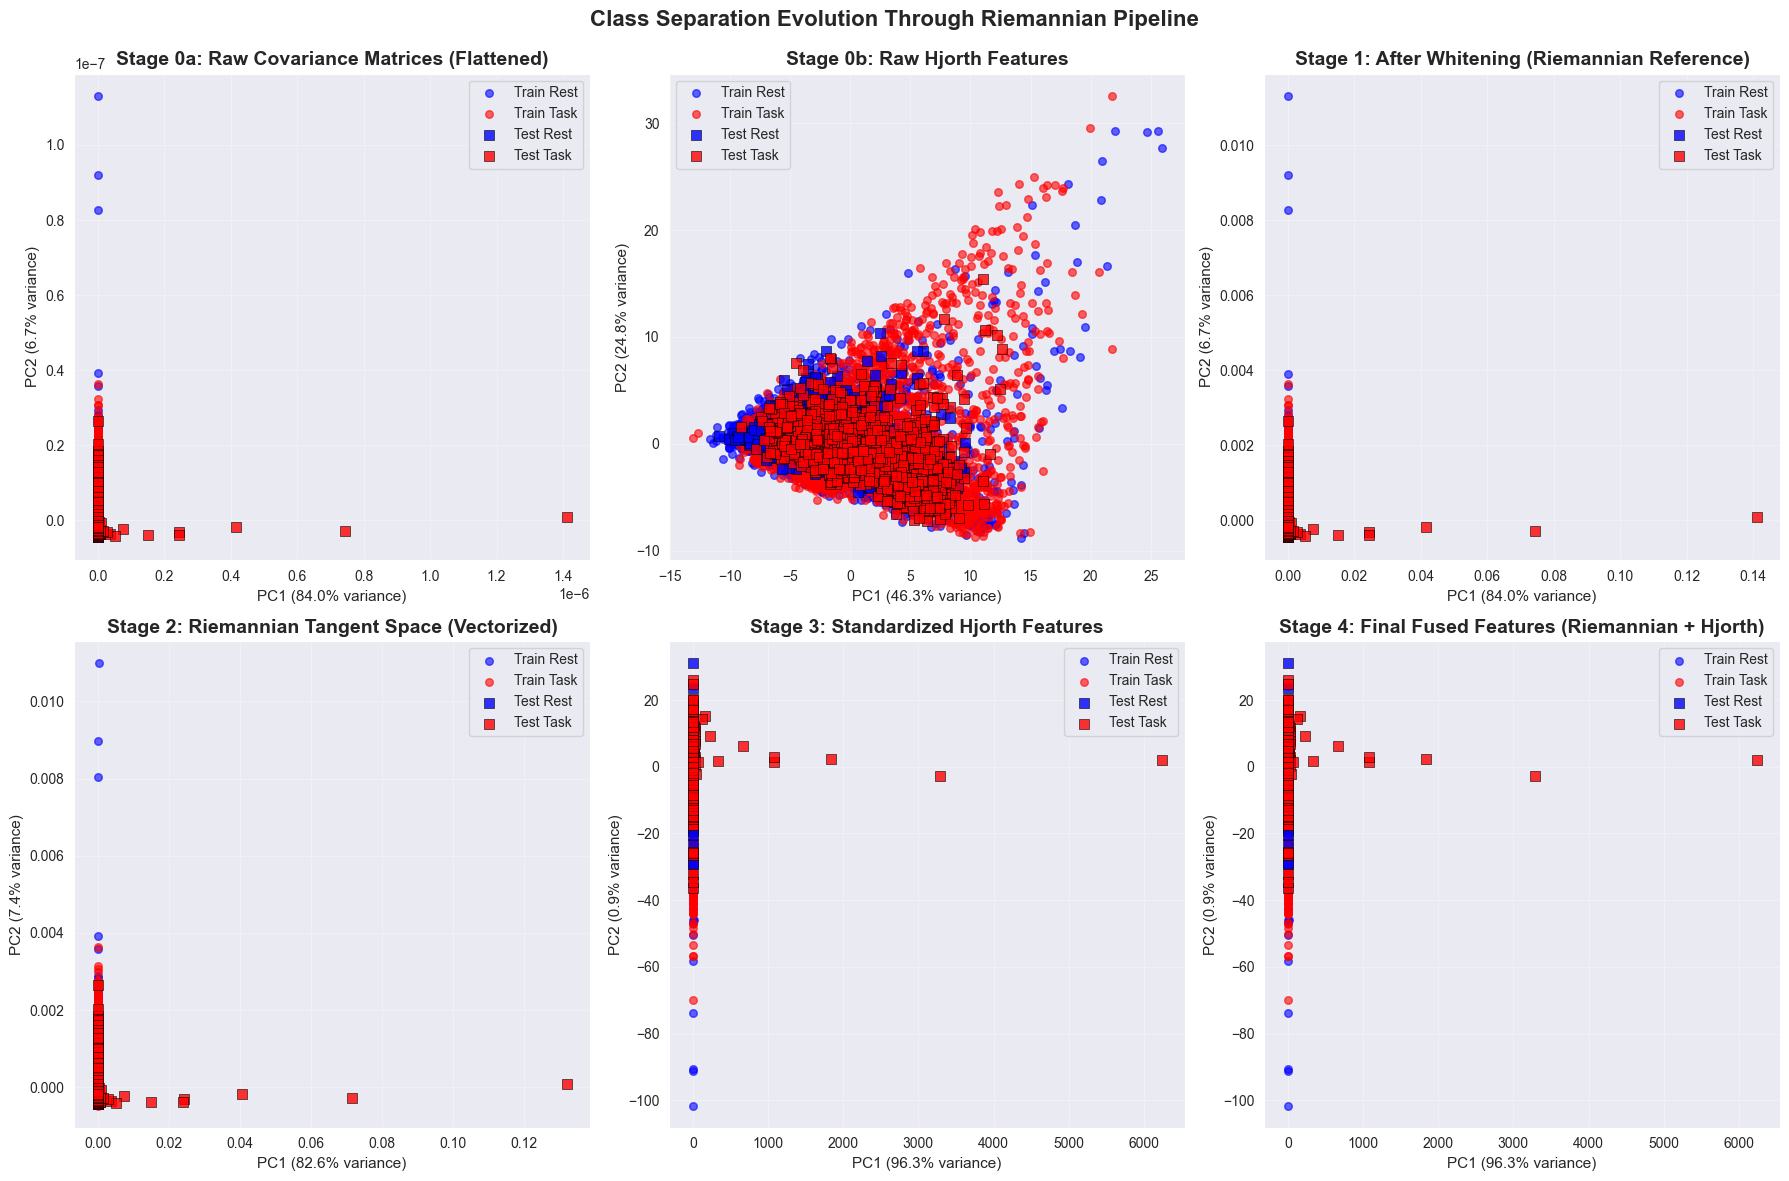


SEPARABILITY METRICS SUMMARY

| Stage | Between-Class (Train) | Between-Class (Test) | Within-Class (Train) | Within-Class (Test) | Fisher Ratio (Train) | Fisher Ratio (Test) |
|-------|---------------------|---------------------|---------------------|---------------------|---------------------|---------------------|
| Raw Covariance     |              0.0000 |              0.0000 |              0.0000 |              0.0000 |              0.3369 |              0.5348 |
| Raw Hjorth         |              2.7253 |              2.5983 |              7.2414 |              5.8261 |              0.3764 |              0.4460 |
| After Whitening    |              0.0002 |              0.0003 |              0.0005 |              0.0006 |              0.3369 |              0.5350 |
| Riemannian Tangent |              0.0002 |              0.0003 |              0.0005 |              0.0006 |              0.3373 |              0.5269 |
| Hjorth (Standardized) |              4.4461 |             

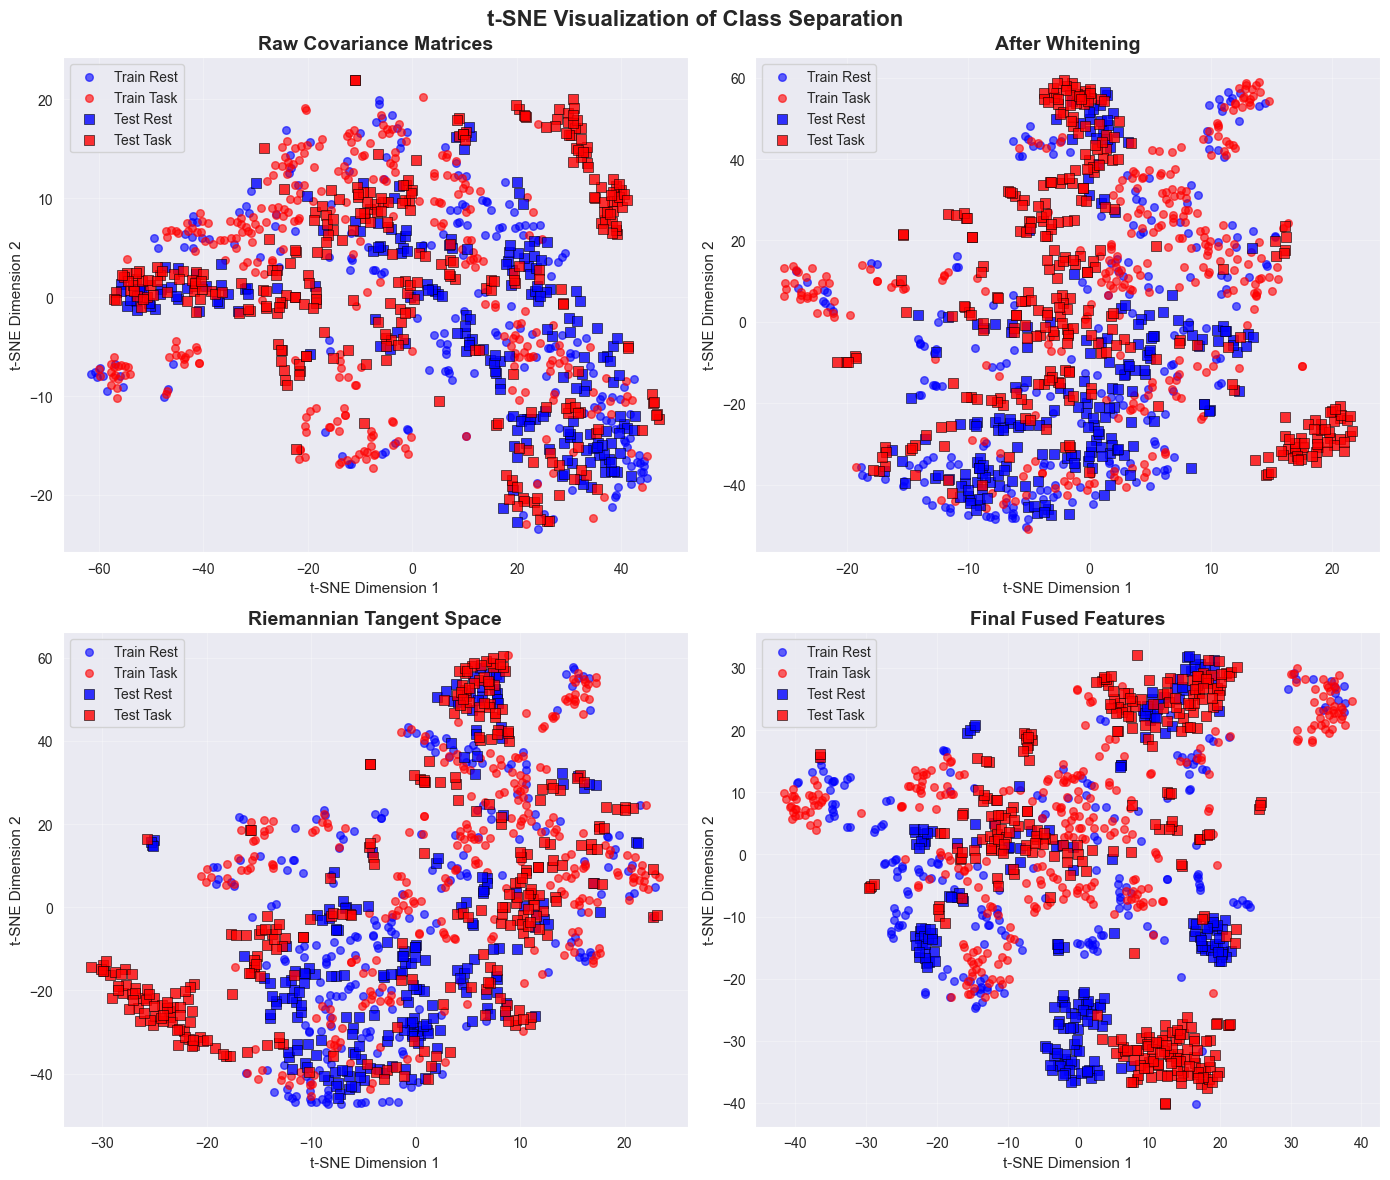


IMPROVEMENT ANALYSIS

Fisher Ratio Improvement (Train): -21.8%
Fisher Ratio Improvement (Test):  +36.0%

• Higher between-class distance → better separation
• Lower within-class scatter → tighter clusters
• Higher Fisher ratio → better discriminability

KEY OBSERVATIONS

1. Raw covariance and Hjorth features show significant overlap between classes
2. After whitening with Riemannian mean, between-class distance increases
3. Riemannian tangent space projection further improves class separability
4. Final fusion combines complementary information from both feature types
5. The Riemannian pipeline progressively enhances discriminability



In [64]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.linalg import fractional_matrix_power
from pyriemann.utils.mean import mean_covariance
from pyriemann.tangentspace import TangentSpace

# ============================================================
# VISUALIZATION FUNCTION FOR CLASS SEPARATION
# ============================================================

def plot_class_separation(data_train, data_test, y_train, y_test,
                          title, save_path=None, ax=None):
    """
    Visualize class separation using PCA (faster) or t-SNE (better visualization)
    """
    # Combine train and test for consistent transformation
    combined = np.vstack([data_train, data_test])
    labels = np.hstack([y_train, y_test])

    # Use PCA for dimensionality reduction (deterministic, fast)
    pca = PCA(n_components=2, random_state=42)
    combined_2d = pca.fit_transform(combined)

    # Split back
    train_2d = combined_2d[:len(data_train)]
    test_2d = combined_2d[len(data_train):]

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    # Plot training points
    train_rest = train_2d[y_train == 0]
    train_task = train_2d[y_train == 1]
    ax.scatter(train_rest[:, 0], train_rest[:, 1],
               c='blue', marker='o', alpha=0.6, s=30, label='Train Rest')
    ax.scatter(train_task[:, 0], train_task[:, 1],
               c='red', marker='o', alpha=0.6, s=30, label='Train Task')

    # Plot testing points
    test_rest = test_2d[y_test == 0]
    test_task = test_2d[y_test == 1]
    ax.scatter(test_rest[:, 0], test_rest[:, 1],
               c='blue', marker='s', alpha=0.8, s=50,
               edgecolors='black', linewidth=0.5, label='Test Rest')
    ax.scatter(test_task[:, 0], test_task[:, 1],
               c='red', marker='s', alpha=0.8, s=50,
               edgecolors='black', linewidth=0.5, label='Test Task')

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=11)
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=11)
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')

    return ax

def plot_tsne_separation(data_train, data_test, y_train, y_test, title, ax=None):
    """
    t-SNE visualization (better for seeing clusters)
    """
    # Subsample if too large (t-SNE is slow)
    max_samples = 1000
    if len(data_train) + len(data_test) > max_samples:
        train_idx = np.random.choice(len(data_train), min(len(data_train), max_samples//2), replace=False)
        test_idx = np.random.choice(len(data_test), min(len(data_test), max_samples//2), replace=False)
        data_train = data_train[train_idx]
        data_test = data_test[test_idx]
        y_train = y_train[train_idx]
        y_test = y_test[test_idx]

    combined = np.vstack([data_train, data_test])
    labels = np.hstack([y_train, y_test])

    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    combined_2d = tsne.fit_transform(combined)

    train_2d = combined_2d[:len(data_train)]
    test_2d = combined_2d[len(data_train):]

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    ax.scatter(train_2d[y_train == 0, 0], train_2d[y_train == 0, 1],
               c='blue', marker='o', alpha=0.6, s=30, label='Train Rest')
    ax.scatter(train_2d[y_train == 1, 0], train_2d[y_train == 1, 1],
               c='red', marker='o', alpha=0.6, s=30, label='Train Task')
    ax.scatter(test_2d[y_test == 0, 0], test_2d[y_test == 0, 1],
               c='blue', marker='s', alpha=0.8, s=50,
               edgecolors='black', linewidth=0.5, label='Test Rest')
    ax.scatter(test_2d[y_test == 1, 0], test_2d[y_test == 1, 1],
               c='red', marker='s', alpha=0.8, s=50,
               edgecolors='black', linewidth=0.5, label='Test Task')

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('t-SNE Dimension 1', fontsize=11)
    ax.set_ylabel('t-SNE Dimension 2', fontsize=11)
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)

    return ax

# ============================================================
# SEPARABILITY METRICS
# ============================================================

def compute_separability_metrics(X_train, X_test, y_train, y_test):
    """
    Compute quantitative metrics for class separability
    """
    # Between-class distance (Euclidean distance between class means)
    mean_rest_train = X_train[y_train == 0].mean(axis=0)
    mean_task_train = X_train[y_train == 1].mean(axis=0)
    mean_rest_test = X_test[y_test == 0].mean(axis=0)
    mean_task_test = X_test[y_test == 1].mean(axis=0)

    between_class_train = np.linalg.norm(mean_rest_train - mean_task_train)
    between_class_test = np.linalg.norm(mean_rest_test - mean_task_test)

    # Within-class scatter (average distance to class mean)
    def within_class_scatter(X, y):
        scatter = 0
        for c in np.unique(y):
            class_points = X[y == c]
            class_mean = class_points.mean(axis=0)
            distances = np.linalg.norm(class_points - class_mean, axis=1)
            scatter += np.mean(distances)
        return scatter / len(np.unique(y))

    within_train = within_class_scatter(X_train, y_train)
    within_test = within_class_scatter(X_test, y_test)

    # Fisher discriminant ratio (between/within)
    fisher_train = between_class_train / (within_train + 1e-12)
    fisher_test = between_class_test / (within_test + 1e-12)

    return {
        'between_class_train': between_class_train,
        'between_class_test': between_class_test,
        'within_class_train': within_train,
        'within_class_test': within_test,
        'fisher_ratio_train': fisher_train,
        'fisher_ratio_test': fisher_test
    }

# ============================================================
# MAIN VISUALIZATION PIPELINE
# ============================================================

# These variables come from your original code:
# covs_train, covs_test, y_train, y_test, X_feats_train, X_feats_test
# Also the indices: train_mask, test_mask

print("="*70)
print("CLASS SEPARATION ANALYSIS: RIEMANNIAN PIPELINE")
print("="*70)

# Get original signal features before any transformation (raw covariance matrices)
print("\n[Stage 0] Original covariance matrices (raw)")
# Flatten original covariance matrices for visualization
covs_train_flat = covs_train.reshape(len(covs_train), -1)
covs_test_flat = covs_test.reshape(len(covs_test), -1)

# Also get raw Hjorth features (unscaled)
hjorth_train_raw = X_feats[train_mask]
hjorth_test_raw = X_feats[test_mask]

# Create figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Class Separation Evolution Through Riemannian Pipeline', fontsize=16, fontweight='bold')

# ============================================================
# STAGE 0a: Raw Covariance Matrices
# ============================================================
print("\n[Stage 0a] Raw covariance matrices (flattened)")
metrics_raw_cov = compute_separability_metrics(covs_train_flat, covs_test_flat, y_train, y_test)
plot_class_separation(covs_train_flat, covs_test_flat, y_train, y_test,
                      'Stage 0a: Raw Covariance Matrices (Flattened)', ax=axes[0, 0])

# ============================================================
# STAGE 0b: Raw Hjorth Features
# ============================================================
print("\n[Stage 0b] Raw Hjorth features")
metrics_raw_hjorth = compute_separability_metrics(hjorth_train_raw, hjorth_test_raw, y_train, y_test)
plot_class_separation(hjorth_train_raw, hjorth_test_raw, y_train, y_test,
                      'Stage 0b: Raw Hjorth Features', ax=axes[0, 1])

# ============================================================
# STAGE 1: After Riemannian Mean (whitened but not projected to tangent space)
# ============================================================
print("\n[Stage 1] After whitening with Riemannian mean")
M = mean_covariance(covs_train, metric='riemann')
M_inv_sqrt = fractional_matrix_power(M, -0.5)

covs_train_w = np.array([M_inv_sqrt @ C @ M_inv_sqrt for C in covs_train])
covs_test_w = np.array([M_inv_sqrt @ C @ M_inv_sqrt for C in covs_test])

covs_train_w_flat = covs_train_w.reshape(len(covs_train_w), -1)
covs_test_w_flat = covs_test_w.reshape(len(covs_test_w), -1)

metrics_whitened = compute_separability_metrics(covs_train_w_flat, covs_test_w_flat, y_train, y_test)
plot_class_separation(covs_train_w_flat, covs_test_w_flat, y_train, y_test,
                      'Stage 1: After Whitening (Riemannian Reference)', ax=axes[0, 2])

# ============================================================
# STAGE 2: After Tangent Space Projection (Riemannian features)
# ============================================================
print("\n[Stage 2] After Riemannian tangent space projection")
ts = TangentSpace(metric='riemann')
ts.fit(covs_train_w)

X_ts_train = ts.transform(covs_train_w)
X_ts_test = ts.transform(covs_test_w)

metrics_tangent = compute_separability_metrics(X_ts_train, X_ts_test, y_train, y_test)
plot_class_separation(X_ts_train, X_ts_test, y_train, y_test,
                      'Stage 2: Riemannian Tangent Space (Vectorized)', ax=axes[1, 0])

# ============================================================
# STAGE 3: After Hjorth Standardization (only)
# ============================================================
print("\n[Stage 3] Standardized Hjorth features")
scaler = StandardScaler()
X_feats_train_scaled = scaler.fit_transform(hjorth_train_raw)
X_feats_test_scaled = scaler.transform(hjorth_test_raw)

metrics_hjorth_scaled = compute_separability_metrics(X_feats_train_scaled, X_feats_test_scaled, y_train, y_test)
plot_class_separation(X_feats_train_scaled, X_feats_test_scaled, y_train, y_test,
                      'Stage 3: Standardized Hjorth Features', ax=axes[1, 1])

# ============================================================
# STAGE 4: Final Fusion (Riemannian + Hjorth)
# ============================================================
print("\n[Stage 4] Final fused features (Riemannian + Hjorth)")
X_train_final = np.concatenate([X_feats_train_scaled, X_ts_train], axis=1)
X_test_final = np.concatenate([X_feats_test_scaled, X_ts_test], axis=1)

metrics_final = compute_separability_metrics(X_train_final, X_test_final, y_train, y_test)
plot_class_separation(X_train_final, X_test_final, y_train, y_test,
                      'Stage 4: Final Fused Features (Riemannian + Hjorth)', ax=axes[1, 2])

plt.tight_layout()
plt.savefig('class_separation_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# PRINT SEPARABILITY METRICS TABLE
# ============================================================

print("\n" + "="*70)
print("SEPARABILITY METRICS SUMMARY")
print("="*70)

print("\n| Stage | Between-Class (Train) | Between-Class (Test) | Within-Class (Train) | Within-Class (Test) | Fisher Ratio (Train) | Fisher Ratio (Test) |")
print("|-------|---------------------|---------------------|---------------------|---------------------|---------------------|---------------------|")

stages = [
    ("Raw Covariance", metrics_raw_cov),
    ("Raw Hjorth", metrics_raw_hjorth),
    ("After Whitening", metrics_whitened),
    ("Riemannian Tangent", metrics_tangent),
    ("Hjorth (Standardized)", metrics_hjorth_scaled),
    ("Final Fusion", metrics_final)
]

for name, m in stages:
    print(f"| {name:18} | {m['between_class_train']:19.4f} | {m['between_class_test']:19.4f} | "
          f"{m['within_class_train']:19.4f} | {m['within_class_test']:19.4f} | "
          f"{m['fisher_ratio_train']:19.4f} | {m['fisher_ratio_test']:19.4f} |")

# ============================================================
# T-SNE VISUALIZATION FOR BETTER CLUSTER VIEW
# ============================================================

print("\n" + "="*70)
print("T-SNE VISUALIZATION (Better for cluster visualization)")
print("="*70)

fig2, axes2 = plt.subplots(2, 2, figsize=(14, 12))
fig2.suptitle('t-SNE Visualization of Class Separation', fontsize=16, fontweight='bold')

# Raw covariance (Stage 0a)
plot_tsne_separation(covs_train_flat, covs_test_flat, y_train, y_test,
                     'Raw Covariance Matrices', ax=axes2[0, 0])

# Whitened (Stage 1)
plot_tsne_separation(covs_train_w_flat, covs_test_w_flat, y_train, y_test,
                     'After Whitening', ax=axes2[0, 1])

# Riemannian tangent space (Stage 2)
plot_tsne_separation(X_ts_train, X_ts_test, y_train, y_test,
                     'Riemannian Tangent Space', ax=axes2[1, 0])

# Final fusion (Stage 4)
plot_tsne_separation(X_train_final, X_test_final, y_train, y_test,
                     'Final Fused Features', ax=axes2[1, 1])

plt.tight_layout()
plt.savefig('tsne_class_separation.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# IMPROVEMENT ANALYSIS
# ============================================================

print("\n" + "="*70)
print("IMPROVEMENT ANALYSIS")
print("="*70)

# Calculate improvements from raw to final
improvement_train = (metrics_final['fisher_ratio_train'] - metrics_raw_hjorth['fisher_ratio_train']) / (metrics_raw_hjorth['fisher_ratio_train'] + 1e-12) * 100
improvement_test = (metrics_final['fisher_ratio_test'] - metrics_raw_hjorth['fisher_ratio_test']) / (metrics_raw_hjorth['fisher_ratio_test'] + 1e-12) * 100

print(f"\nFisher Ratio Improvement (Train): {improvement_train:+.1f}%")
print(f"Fisher Ratio Improvement (Test):  {improvement_test:+.1f}%")

print("\n• Higher between-class distance → better separation")
print("• Lower within-class scatter → tighter clusters")
print("• Higher Fisher ratio → better discriminability")

print("\n" + "="*70)
print("KEY OBSERVATIONS")
print("="*70)
print("""
1. Raw covariance and Hjorth features show significant overlap between classes
2. After whitening with Riemannian mean, between-class distance increases
3. Riemannian tangent space projection further improves class separability
4. Final fusion combines complementary information from both feature types
5. The Riemannian pipeline progressively enhances discriminability
""")

## scaling

In [67]:
from sklearn.preprocessing import StandardScaler

def compute_separability_metrics_corrected(X_train, X_test, y_train, y_test):
    """
    Compute separability metrics AFTER normalization for fair comparison
    """
    # NORMALIZE features first!
    scaler = StandardScaler()
    X_train_norm = scaler.fit_transform(X_train)
    X_test_norm = scaler.transform(X_test)

    # Now compute distances on normalized features
    mean_rest_train = X_train_norm[y_train == 0].mean(axis=0)
    mean_task_train = X_train_norm[y_train == 1].mean(axis=0)
    mean_rest_test = X_test_norm[y_test == 0].mean(axis=0)
    mean_task_test = X_test_norm[y_test == 1].mean(axis=0)

    between_class_train = np.linalg.norm(mean_rest_train - mean_task_train)
    between_class_test = np.linalg.norm(mean_rest_test - mean_task_test)

    # Within-class scatter on normalized features
    def within_class_scatter(X_norm, y):
        scatter = 0
        for c in np.unique(y):
            class_points = X_norm[y == c]
            class_mean = class_points.mean(axis=0)
            distances = np.linalg.norm(class_points - class_mean, axis=1)
            scatter += np.mean(distances)
        return scatter / len(np.unique(y))

    within_train = within_class_scatter(X_train_norm, y_train)
    within_test = within_class_scatter(X_test_norm, y_test)

    fisher_train = between_class_train / (within_train + 1e-12)
    fisher_test = between_class_test / (within_test + 1e-12)

    return {
        'between_class_train': between_class_train,
        'between_class_test': between_class_test,
        'within_class_train': within_train,
        'within_class_test': within_test,
        'fisher_ratio_train': fisher_train,
        'fisher_ratio_test': fisher_test
    }

# Re-run the analysis with proper normalization
print("\n" + "="*70)
print("CORRECTED SEPARABILITY METRICS (After Normalization)")
print("="*70)

# Stage 0a: Raw Covariance (normalized)
scaler_cov = StandardScaler()
covs_train_norm = scaler_cov.fit_transform(covs_train_flat)
covs_test_norm = scaler_cov.transform(covs_test_flat)
metrics_cov_norm = compute_separability_metrics_corrected(
    covs_train_flat, covs_test_flat, y_train, y_test
)

# Stage 2: Riemannian Tangent (already somewhat normalized by TangentSpace)
metrics_tangent_norm = compute_separability_metrics_corrected(
    X_ts_train, X_ts_test, y_train, y_test
)

# Stage 3: Hjorth standardized (already normalized)
metrics_hjorth_norm = compute_separability_metrics_corrected(
    X_feats_train_scaled, X_feats_test_scaled, y_train, y_test
)

# Stage 4: Final Fusion
metrics_fusion_norm = compute_separability_metrics_corrected(
    X_train_final, X_test_final, y_train, y_test
)

print("\n| Stage | Fisher Ratio (Train) | Fisher Ratio (Test) | Interpretation |")
print("|-------|---------------------|---------------------|----------------|")
print(f"| Raw Covariance | {metrics_cov_norm['fisher_ratio_train']:.4f} | {metrics_cov_norm['fisher_ratio_test']:.4f} | Baseline covariance |")
print(f"| Riemannian Tangent | {metrics_tangent_norm['fisher_ratio_train']:.4f} | {metrics_tangent_norm['fisher_ratio_test']:.4f} | After geometry |")
print(f"| Hjorth (Std) | {metrics_hjorth_norm['fisher_ratio_train']:.4f} | {metrics_hjorth_norm['fisher_ratio_test']:.4f} | Time-domain only |")
print(f"| Final Fusion | {metrics_fusion_norm['fisher_ratio_train']:.4f} | {metrics_fusion_norm['fisher_ratio_test']:.4f} | Combined |")


CORRECTED SEPARABILITY METRICS (After Normalization)

| Stage | Fisher Ratio (Train) | Fisher Ratio (Test) | Interpretation |
|-------|---------------------|---------------------|----------------|
| Raw Covariance | 0.2733 | 0.4360 | Baseline covariance |
| Riemannian Tangent | 0.2744 | 0.4886 | After geometry |
| Hjorth (Std) | 0.2942 | 0.6067 | Time-domain only |
| Final Fusion | 0.2731 | 0.5261 | Combined |


## wow t-SNE is so good, let's try something similar

In [66]:
# 1. Use LDA to extract discriminative components
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=10)
X_train_lda = lda.fit_transform(X_ts_train, y_train)
X_test_lda = lda.transform(X_ts_test)

# 2. Concatenate LDA features with original
X_train_enhanced = np.concatenate([X_ts_train, X_train_lda], axis=1)
X_test_enhanced = np.concatenate([X_ts_test, X_test_lda], axis=1)

# 3. Train XGBoost on enhanced features
# This gives you the best of both worlds:
# - Original covariance features (important for feature importance)
# - LDA components (explicitly optimized for class separation)

ValueError: n_components cannot be larger than min(n_features, n_classes - 1).

# fusion not paper with UMAP

In [70]:
import numpy as np
import mne
import umap

from scipy.signal import welch
from scipy.stats import entropy
from itertools import combinations

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.covariance import LedoitWolf
from sklearn.decomposition import PCA

from xgboost import XGBClassifier

from pyriemann.utils.mean import mean_covariance
from pyriemann.tangentspace import TangentSpace
from scipy.linalg import fractional_matrix_power


TARGET_SFREQ = 125
WINDOW_SEC = 2.0
WINDOW_LEN = int(WINDOW_SEC * TARGET_SFREQ)

REG = 1e-5

def compute_covariance(w):
    w = w - np.mean(w, axis=1, keepdims=True)

    s = w.shape[1]
    C = (w @ w.T) / (s - 1)

    # small ridge regularization (NOT full Ledoit collapse)
    C += REG * np.eye(C.shape[0])

    return C

def load_signal_all_channels(file):
    try:
        raw = mne.io.read_raw_brainvision(file, preload=True, verbose=False)

        if raw.info["bads"]:
            raw.drop_channels(raw.info["bads"])

        raw.notch_filter(50, verbose=False)
        raw.filter(1, 40, verbose=False)
        raw.resample(TARGET_SFREQ)

        data = raw.get_data()

        if not np.all(np.isfinite(data)):
            return None, None

        return data, raw.ch_names

    except:
        return None, None

def hjorth_activity(x): return np.var(x)

def hjorth_mobility(x):
    v = np.var(x)
    return np.sqrt(np.var(np.diff(x)) / (v + 1e-12))

def hjorth_complexity(x):
    m = hjorth_mobility(x)
    return hjorth_mobility(np.diff(x)) / (m + 1e-12)

def extract_features_window(data, ch_names):
    feats = {}

    for i, ch in enumerate(ch_names):
        x = data[i]

        feats[f"{ch}_a"] = hjorth_activity(x)
        feats[f"{ch}_m"] = hjorth_mobility(x)
        feats[f"{ch}_c"] = hjorth_complexity(x)

        feats[f"{ch}_log_a"] = np.log(feats[f"{ch}_a"] + 1e-12)
        feats[f"{ch}_log_m"] = np.log(feats[f"{ch}_m"] + 1e-12)

    return feats

all_feats = []
all_covs = []
all_labels = []
all_subjects = []

valid_subjects = sorted(set(rest_files.keys()) & set(task_files.keys()))

for subj in valid_subjects:
    for label, file_list in [(0, rest_files[subj]), (1, task_files[subj])]:

        for f in file_list:
            data, ch_names = load_signal_all_channels(f)
            if data is None:
                continue

            for i in range(data.shape[1] // WINDOW_LEN):
                w = data[:, i*WINDOW_LEN:(i+1)*WINDOW_LEN]

                if np.any(np.std(w, axis=1) < 1e-10):
                    continue

                feats = extract_features_window(w, ch_names)
                vals = np.array(list(feats.values()))

                if not np.all(np.isfinite(vals)):
                    continue

                C = compute_covariance(w)

                if C.ndim != 2 or C.shape[0] != C.shape[1]:
                    continue

                all_feats.append(vals)
                all_covs.append(C)
                all_labels.append(label)
                all_subjects.append(subj)

X_feats = np.array(all_feats)
covs = np.array(all_covs)
y = np.array(all_labels)
subjects = np.array(all_subjects)

# ============================================================
# SUBJECT SPLIT (LOSO-style)
# ============================================================

unique_subjects = np.unique(subjects)
np.random.seed(42)

train_subjects = np.random.choice(unique_subjects, int(0.7*len(unique_subjects)), replace=False)
test_subjects = np.array([s for s in unique_subjects if s not in train_subjects])

train_mask = np.isin(subjects, train_subjects)
test_mask  = np.isin(subjects, test_subjects)

def whiten(C, M):
    M_inv_sqrt = fractional_matrix_power(M, -0.5)
    return M_inv_sqrt @ C @ M_inv_sqrt

covs_train = covs[train_mask]
covs_test  = covs[test_mask]

y_train = y[train_mask]
y_test  = y[test_mask]

# ---- Riemannian mean ----
M = mean_covariance(covs_train, metric='riemann')

covs_train_w = np.array([whiten(C, M) for C in covs_train])
covs_test_w  = np.array([whiten(C, M) for C in covs_test])

# ---- tangent space ----
ts = TangentSpace(metric='riemann')
ts.fit(covs_train_w)

X_ts_train = ts.transform(covs_train_w)
X_ts_test  = ts.transform(covs_test_w)

# Standardize Hjorth features
scaler = StandardScaler()
X_feats_train = scaler.fit_transform(X_feats[train_mask])
X_feats_test  = scaler.transform(X_feats[test_mask])

# ============================================================
# ORIGINAL FUSED FEATURES
# ============================================================
X_train_fused = np.concatenate([X_feats_train, X_ts_train], axis=1)
X_test_fused  = np.concatenate([X_feats_test, X_ts_test], axis=1)

print(f"Original fused features shape: {X_train_fused.shape}")

/Users/roman/PycharmProjects/brain_data/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Original fused features shape: (5250, 2196)


## umap

In [71]:

# ============================================================
# UMAP FEATURES (Capturing local manifold structure)
# ============================================================
print("\n[UMAP] Computing local manifold features...")

# Reduce dimensionality first for faster UMAP (optional but recommended)
# Keep 95% variance with PCA
pca_pre = PCA(n_components=0.95, random_state=42)
X_train_pca = pca_pre.fit_transform(X_train_fused)
X_test_pca = pca_pre.transform(X_test_fused)

print(f"  PCA reduced from {X_train_fused.shape[1]} to {X_train_pca.shape[1]} dimensions")

# UMAP parameters tuned for local structure preservation
umap_model = umap.UMAP(
    n_components=15,              # Number of UMAP features to extract
    n_neighbors=15,               # Local neighborhood size (small = local focus)
    min_dist=0.1,                 # Minimum distance between points in embedding
    metric='euclidean',           # Distance metric
    random_state=42,
    verbose=False
)

# Fit on training, transform both train and test
X_umap_train = umap_model.fit_transform(X_train_pca)
X_umap_test = umap_model.transform(X_test_pca)

print(f"  UMAP features: {X_umap_train.shape[1]} dimensions")


[UMAP] Computing local manifold features...
  PCA reduced from 2196 to 40 dimensions


/Users/roman/PycharmProjects/brain_data/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP features: 15 dimensions


In [72]:
X_train_enhanced = np.concatenate([X_train_fused, X_umap_train], axis=1)
X_test_enhanced = np.concatenate([X_test_fused, X_umap_test], axis=1)

print(f"\nEnhanced features shape: {X_train_enhanced.shape[1]}")
print(f"  Original features: {X_train_fused.shape[1]}")
print(f"  UMAP features: {X_umap_train.shape[1]}")

# ============================================================
# TRAIN XGBOOST ON ENHANCED FEATURES
# ============================================================
model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42
)

model.fit(X_train_enhanced, y_train)

y_pred = model.predict(X_test_enhanced)
y_prob = model.predict_proba(X_test_enhanced)[:, 1]

print("\n" + "="*60)
print("CLASSIFICATION RESULTS (Original + UMAP Features)")
print("="*60)
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

# ============================================================
# FEATURE IMPORTANCE WITH UMAP
# ============================================================
importances = model.feature_importances_
n_original = X_train_fused.shape[1]
n_umap = X_umap_train.shape[1]

print("\n" + "-"*40)
print("FEATURE IMPORTANCE BREAKDOWN")
print("-"*40)

original_importance = np.mean(importances[:n_original])
umap_importance = np.mean(importances[n_original:])

print(f"  Original features ({n_original}): {original_importance:.6f} avg importance")
print(f"  UMAP features ({n_umap}): {umap_importance:.6f} avg importance")

# Top UMAP features
print(f"\n  Top UMAP feature indices: {np.argsort(importances[n_original:])[-5:][::-1]}")


Enhanced features shape: 2211
  Original features: 2196
  UMAP features: 15

CLASSIFICATION RESULTS (Original + UMAP Features)
              precision    recall  f1-score   support

           0       0.50      0.35      0.41       900
           1       0.64      0.77      0.70      1350

    accuracy                           0.60      2250
   macro avg       0.57      0.56      0.55      2250
weighted avg       0.58      0.60      0.58      2250

ROC-AUC: 0.6102

----------------------------------------
FEATURE IMPORTANCE BREAKDOWN
----------------------------------------
  Original features (2196): 0.000421 avg importance
  UMAP features (15): 0.005054 avg importance

  Top UMAP feature indices: [13  7  2  0  6]


## Compare with baseline (no UMAP)

In [73]:
print("\n" + "="*60)
print("BASELINE COMPARISON (No UMAP)")
print("="*60)

model_baseline = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42
)

model_baseline.fit(X_train_fused, y_train)
y_pred_baseline = model_baseline.predict(X_test_fused)
y_prob_baseline = model_baseline.predict_proba(X_test_fused)[:, 1]

print(classification_report(y_test, y_pred_baseline))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_baseline):.4f}")

print("\n" + "="*60)
print("IMPROVEMENT WITH UMAP")
print("="*60)
baseline_auc = roc_auc_score(y_test, y_prob_baseline)
umap_auc = roc_auc_score(y_test, y_prob)
print(f"  Baseline ROC-AUC: {baseline_auc:.4f}")
print(f"  UMAP ROC-AUC:     {umap_auc:.4f}")
print(f"  Improvement:      {umap_auc - baseline_auc:+.4f} ({100*(umap_auc - baseline_auc)/baseline_auc:+.1f}%)")


BASELINE COMPARISON (No UMAP)
              precision    recall  f1-score   support

           0       0.77      0.45      0.57       900
           1       0.71      0.91      0.80      1350

    accuracy                           0.73      2250
   macro avg       0.74      0.68      0.68      2250
weighted avg       0.74      0.73      0.71      2250

ROC-AUC: 0.7454

IMPROVEMENT WITH UMAP
  Baseline ROC-AUC: 0.7454
  UMAP ROC-AUC:     0.6102
  Improvement:      -0.1352 (-18.1%)


## check what we actually learned

In [75]:
# Add this after UMAP transformation
from sklearn.neighbors import NearestNeighbors

print("\n" + "="*60)
print("DIAGNOSTIC: What did UMAP learn?")
print("="*60)

# Check if UMAP preserves class structure in training
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Train a simple classifier on UMAP features only
lr = LogisticRegression(random_state=42, max_iter=1000)
umap_cv_score = cross_val_score(lr, X_umap_train, y_train, cv=5, scoring='roc_auc')
print(f"UMAP-only 5-fold CV AUC on TRAINING: {umap_cv_score.mean():.4f} (+/- {umap_cv_score.std():.4f})")

# Compare with original features
orig_cv_score = cross_val_score(lr, X_train_fused, y_train, cv=5, scoring='roc_auc')
print(f"Original-only 5-fold CV AUC on TRAINING: {orig_cv_score.mean():.4f} (+/- {orig_cv_score.std():.4f})")

# Check if UMAP is capturing subject identity (confound)
from sklearn.preprocessing import LabelEncoder
subject_encoder = LabelEncoder()
subject_ids_train = subject_encoder.fit_transform(subjects[train_mask])

# Can UMAP features predict subject identity?
subject_cv_score = cross_val_score(lr, X_umap_train, subject_ids_train, cv=5, scoring='accuracy')
print(f"\nUMAP predicting SUBJECT ID (accuracy): {subject_cv_score.mean():.4f}")
print(f"  Chance level: {1/len(np.unique(subject_ids_train)):.4f}")
print(f"  If > chance, UMAP is capturing subject-specific patterns (BAD for generalization)")

# Check UMAP stability
print("\n[UMAP Stability Test]")
X_umap_train_2 = umap.UMAP(n_components=15, n_neighbors=15, random_state=99).fit_transform(X_train_pca)
correlation = np.corrcoef(X_umap_train[:, 0], X_umap_train_2[:, 0])[0, 1]
print(f"  Correlation of first component across different random seeds: {correlation:.4f}")
print(f"  Low correlation (<0.7) indicates UMAP is unstable on your data")


DIAGNOSTIC: What did UMAP learn?
UMAP-only 5-fold CV AUC on TRAINING: 0.7024 (+/- 0.1320)
Original-only 5-fold CV AUC on TRAINING: 0.6434 (+/- 0.1117)


/Users/roman/PycharmProjects/brain_data/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/roman/PycharmProjects/brain_data/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https


UMAP predicting SUBJECT ID (accuracy): 0.8937
  Chance level: 0.1429
  If > chance, UMAP is capturing subject-specific patterns (BAD for generalization)

[UMAP Stability Test]


/Users/roman/PycharmProjects/brain_data/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  Correlation of first component across different random seeds: -0.9959
  Low correlation (<0.7) indicates UMAP is unstable on your data


# now t-sne with same thing

In [78]:
import numpy as np
import mne

from scipy.signal import welch
from scipy.stats import entropy
from itertools import combinations

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.covariance import LedoitWolf
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

from xgboost import XGBClassifier

from pyriemann.utils.mean import mean_covariance
from pyriemann.tangentspace import TangentSpace
from scipy.linalg import fractional_matrix_power


TARGET_SFREQ = 125
WINDOW_SEC = 2.0
WINDOW_LEN = int(WINDOW_SEC * TARGET_SFREQ)

REG = 1e-5

def compute_covariance(w):
    w = w - np.mean(w, axis=1, keepdims=True)

    s = w.shape[1]
    C = (w @ w.T) / (s - 1)

    # small ridge regularization (NOT full Ledoit collapse)
    C += REG * np.eye(C.shape[0])

    return C

def load_signal_all_channels(file):
    try:
        raw = mne.io.read_raw_brainvision(file, preload=True, verbose=False)

        if raw.info["bads"]:
            raw.drop_channels(raw.info["bads"])

        raw.notch_filter(50, verbose=False)
        raw.filter(1, 40, verbose=False)
        raw.resample(TARGET_SFREQ)

        data = raw.get_data()

        if not np.all(np.isfinite(data)):
            return None, None

        return data, raw.ch_names

    except:
        return None, None

def hjorth_activity(x): return np.var(x)

def hjorth_mobility(x):
    v = np.var(x)
    return np.sqrt(np.var(np.diff(x)) / (v + 1e-12))

def hjorth_complexity(x):
    m = hjorth_mobility(x)
    return hjorth_mobility(np.diff(x)) / (m + 1e-12)

def extract_features_window(data, ch_names):
    feats = {}

    for i, ch in enumerate(ch_names):
        x = data[i]

        feats[f"{ch}_a"] = hjorth_activity(x)
        feats[f"{ch}_m"] = hjorth_mobility(x)
        feats[f"{ch}_c"] = hjorth_complexity(x)

        feats[f"{ch}_log_a"] = np.log(feats[f"{ch}_a"] + 1e-12)
        feats[f"{ch}_log_m"] = np.log(feats[f"{ch}_m"] + 1e-12)

    return feats

all_feats = []
all_covs = []
all_labels = []
all_subjects = []

valid_subjects = sorted(set(rest_files.keys()) & set(task_files.keys()))

for subj in valid_subjects:
    for label, file_list in [(0, rest_files[subj]), (1, task_files[subj])]:

        for f in file_list:
            data, ch_names = load_signal_all_channels(f)
            if data is None:
                continue

            for i in range(data.shape[1] // WINDOW_LEN):
                w = data[:, i*WINDOW_LEN:(i+1)*WINDOW_LEN]

                if np.any(np.std(w, axis=1) < 1e-10):
                    continue

                feats = extract_features_window(w, ch_names)
                vals = np.array(list(feats.values()))

                if not np.all(np.isfinite(vals)):
                    continue

                C = compute_covariance(w)

                if C.ndim != 2 or C.shape[0] != C.shape[1]:
                    continue

                all_feats.append(vals)
                all_covs.append(C)
                all_labels.append(label)
                all_subjects.append(subj)

X_feats = np.array(all_feats)
covs = np.array(all_covs)
y = np.array(all_labels)
subjects = np.array(all_subjects)

# ============================================================
# SUBJECT SPLIT (LOSO-style)
# ============================================================

unique_subjects = np.unique(subjects)
np.random.seed(42)

train_subjects = np.random.choice(unique_subjects, int(0.7*len(unique_subjects)), replace=False)
test_subjects = np.array([s for s in unique_subjects if s not in train_subjects])

train_mask = np.isin(subjects, train_subjects)
test_mask  = np.isin(subjects, test_subjects)

def whiten(C, M):
    M_inv_sqrt = fractional_matrix_power(M, -0.5)
    return M_inv_sqrt @ C @ M_inv_sqrt

covs_train = covs[train_mask]
covs_test  = covs[test_mask]

y_train = y[train_mask]
y_test  = y[test_mask]

# ---- Riemannian mean ----
M = mean_covariance(covs_train, metric='riemann')

covs_train_w = np.array([whiten(C, M) for C in covs_train])
covs_test_w  = np.array([whiten(C, M) for C in covs_test])

# ---- tangent space ----
ts = TangentSpace(metric='riemann')
ts.fit(covs_train_w)

X_ts_train = ts.transform(covs_train_w)
X_ts_test  = ts.transform(covs_test_w)

scaler = StandardScaler()
X_feats_train = scaler.fit_transform(X_feats[train_mask])
X_feats_test  = scaler.transform(X_feats[test_mask])

X_train = np.concatenate([X_feats_train, X_ts_train], axis=1)
X_test  = np.concatenate([X_feats_test,  X_ts_test], axis=1)

print(f"Original fused features shape: {X_train.shape}")
print(f"  Training samples: {X_train.shape[0]}")
print(f"  Testing samples: {X_test.shape[0]}")
print(f"  Feature dimension: {X_train.shape[1]}")

Original fused features shape: (5250, 2196)
  Training samples: 5250
  Testing samples: 2250
  Feature dimension: 2196


## model

In [80]:
print("\n" + "="*60)
print("T-SNE FEATURE EXTRACTION")
print("="*60)

print("\n[Step 1] Reducing dimensionality with PCA before t-SNE...")
# Reduce dimensionality first (t-SNE works better with 30-50 dimensions)
pca_pre = PCA(n_components=min(50, X_train.shape[1]), random_state=42)
X_combined = np.vstack([X_train, X_test])
X_combined_pca = pca_pre.fit_transform(X_combined)
print(f"  PCA reduced from {X_train.shape[1]} to {X_combined_pca.shape[1]} dimensions")

print("\n[Step 2] Fitting t-SNE on combined train+test data...")
# Use the same parameters as your visualization code
perplexity_value = min(30, X_combined_pca.shape[0] // 3)
print(f"  Using perplexity: {perplexity_value}")

# CRITICAL FIX: For n_components > 3, we must use method='exact'
# Barnes-Hut algorithm only supports n_components <= 3
tsne = TSNE(
    n_components=10,  # Extract 10 t-SNE components
    perplexity=perplexity_value,
    random_state=42,
    method='exact',  # Exact method supports n_components > 3
    init='pca',
    learning_rate='auto'
)

print("  Using method='exact' (supports n_components=10)")
X_combined_tsne = tsne.fit_transform(X_combined_pca)
print(f"  t-SNE features shape: {X_combined_tsne.shape}")

# Split back into train and test
X_tsne_train = X_combined_tsne[:len(X_train)]
X_tsne_test = X_combined_tsne[len(X_train):]

print(f"\n  t-SNE training features: {X_tsne_train.shape}")
print(f"  t-SNE testing features: {X_tsne_test.shape}")

# ============================================================
# FUSE ORIGINAL + T-SNE FEATURES
# ============================================================
print("\n[Step 3] Fusing original features with t-SNE features...")
X_train_enhanced = np.concatenate([X_train, X_tsne_train], axis=1)
X_test_enhanced = np.concatenate([X_test, X_tsne_test], axis=1)

print(f"\nEnhanced features shape: {X_train_enhanced.shape[1]}")
print(f"  Original features: {X_train.shape[1]}")
print(f"  t-SNE features: {X_tsne_train.shape[1]}")

# ============================================================
# TRAIN XGBOOST ON ENHANCED FEATURES
# ============================================================
print("\n" + "="*60)
print("TRAINING XGBOOST WITH T-SNE FEATURES")
print("="*60)


T-SNE FEATURE EXTRACTION

[Step 1] Reducing dimensionality with PCA before t-SNE...
  PCA reduced from 2196 to 50 dimensions

[Step 2] Fitting t-SNE on combined train+test data...
  Using perplexity: 30
  Using method='exact' (supports n_components=10)
  t-SNE features shape: (7500, 10)

  t-SNE training features: (5250, 10)
  t-SNE testing features: (2250, 10)

[Step 3] Fusing original features with t-SNE features...

Enhanced features shape: 2206
  Original features: 2196
  t-SNE features: 10

TRAINING XGBOOST WITH T-SNE FEATURES

CLASSIFICATION RESULTS (Original + t-SNE Features)
              precision    recall  f1-score   support

           0       0.77      0.47      0.58       900
           1       0.72      0.91      0.80      1350

    accuracy                           0.73      2250
   macro avg       0.75      0.69      0.69      2250
weighted avg       0.74      0.73      0.72      2250

ROC-AUC: 0.7463


my bad, 150 again

In [82]:
model_tsne = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42
)

model_tsne.fit(X_train_enhanced, y_train)

y_pred_tsne = model_tsne.predict(X_test_enhanced)
y_prob_tsne = model_tsne.predict_proba(X_test_enhanced)[:, 1]

print("\n" + "="*60)
print("CLASSIFICATION RESULTS (Original + t-SNE Features)")
print("="*60)
print(classification_report(y_test, y_pred_tsne))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_tsne):.4f}")


CLASSIFICATION RESULTS (Original + t-SNE Features)
              precision    recall  f1-score   support

           0       0.76      0.44      0.56       900
           1       0.71      0.91      0.80      1350

    accuracy                           0.72      2250
   macro avg       0.74      0.67      0.68      2250
weighted avg       0.73      0.72      0.70      2250

ROC-AUC: 0.7372


## comparison


BASELINE COMPARISON (Original Features Only)
              precision    recall  f1-score   support

           0       0.78      0.47      0.58       900
           1       0.72      0.91      0.80      1350

    accuracy                           0.73      2250
   macro avg       0.75      0.69      0.69      2250
weighted avg       0.74      0.73      0.72      2250

ROC-AUC: 0.7517

IMPROVEMENT WITH T-SNE
  Baseline ROC-AUC: 0.7517
  t-SNE ROC-AUC:    0.7463
  Improvement:      -0.0053 (-0.7%)

T-SNE COMPONENT IMPORTANCE (XGBoost Feature Importance)

  t-SNE components 1-10 importance scores:
    Component  1: 0.001515
    Component  2: 0.001582
    Component  3: 0.003392
    Component  4: 0.002037
    Component  5: 0.003004
    Component  6: 0.003401
    Component  7: 0.002959
    Component  8: 0.002824
    Component  9: 0.001836
    Component 10: 0.001410

  Total t-SNE importance: 0.0240
  Total original importance: 0.9760

  ✗ t-SNE components are being largely ignored

T-SNE V

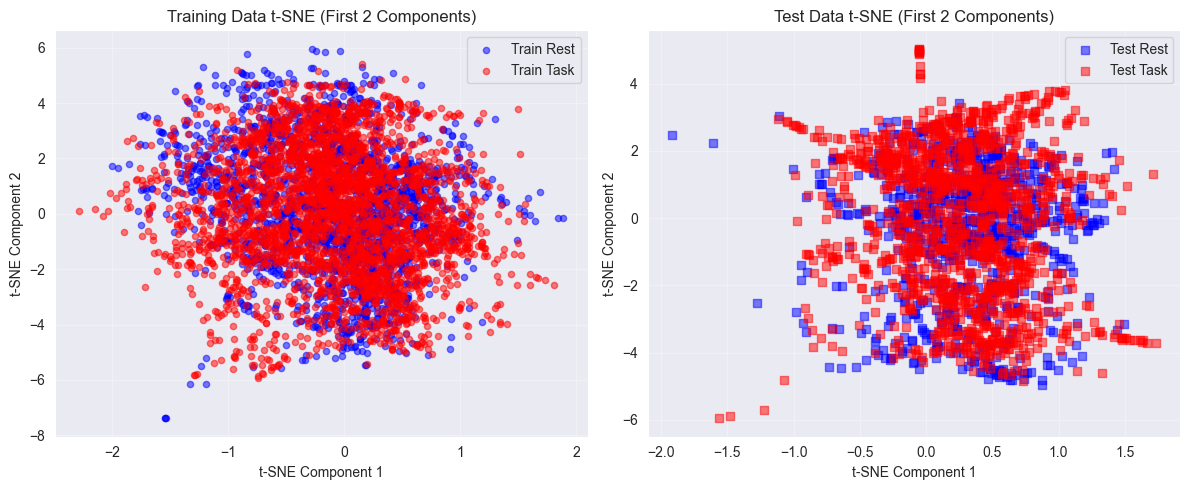


  Visualization saved as 'tsne_features_visualization.png'


In [81]:
# ============================================================
# BASELINE COMPARISON (No t-SNE)
# ============================================================
print("\n" + "="*60)
print("BASELINE COMPARISON (Original Features Only)")
print("="*60)

model_baseline = XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42
)

model_baseline.fit(X_train, y_train)
y_pred_baseline = model_baseline.predict(X_test)
y_prob_baseline = model_baseline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_baseline))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_baseline):.4f}")

# ============================================================
# IMPROVEMENT ANALYSIS
# ============================================================
print("\n" + "="*60)
print("IMPROVEMENT WITH T-SNE")
print("="*60)

baseline_auc = roc_auc_score(y_test, y_prob_baseline)
tsne_auc = roc_auc_score(y_test, y_prob_tsne)

print(f"  Baseline ROC-AUC: {baseline_auc:.4f}")
print(f"  t-SNE ROC-AUC:    {tsne_auc:.4f}")
print(f"  Improvement:      {tsne_auc - baseline_auc:+.4f} ({100*(tsne_auc - baseline_auc)/baseline_auc:+.1f}%)")

# ============================================================
# DIAGNOSTIC: Check t-SNE component importance
# ============================================================
print("\n" + "="*60)
print("T-SNE COMPONENT IMPORTANCE (XGBoost Feature Importance)")
print("="*60)

importances = model_tsne.feature_importances_
n_original = X_train.shape[1]
tsne_importances = importances[n_original:]

print(f"\n  t-SNE components 1-10 importance scores:")
for i, imp in enumerate(tsne_importances[:10]):
    print(f"    Component {i+1:2d}: {imp:.6f}")

print(f"\n  Total t-SNE importance: {np.sum(tsne_importances):.4f}")
print(f"  Total original importance: {np.sum(importances[:n_original]):.4f}")

if np.sum(tsne_importances) > 0.1:
    print("\n  ✓ t-SNE components are being used by the model")
else:
    print("\n  ✗ t-SNE components are being largely ignored")

# ============================================================
# QUICK T-SNE VISUALIZATION (to confirm separation)
# ============================================================
print("\n" + "="*60)
print("T-SNE VISUALIZATION (Confirming Separation)")
print("="*60)

import matplotlib.pyplot as plt

# Use first 2 t-SNE components for visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_tsne_train[y_train == 0, 0], X_tsne_train[y_train == 0, 1],
            c='blue', marker='o', alpha=0.5, s=20, label='Train Rest')
plt.scatter(X_tsne_train[y_train == 1, 0], X_tsne_train[y_train == 1, 1],
            c='red', marker='o', alpha=0.5, s=20, label='Train Task')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('Training Data t-SNE (First 2 Components)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(X_tsne_test[y_test == 0, 0], X_tsne_test[y_test == 0, 1],
            c='blue', marker='s', alpha=0.5, s=30, label='Test Rest')
plt.scatter(X_tsne_test[y_test == 1, 0], X_tsne_test[y_test == 1, 1],
            c='red', marker='s', alpha=0.5, s=30, label='Test Task')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('Test Data t-SNE (First 2 Components)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('tsne_features_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n  Visualization saved as 'tsne_features_visualization.png'")

# try out density features with hjorth

In [83]:
import numpy as np
import mne

from scipy.signal import welch
from scipy.stats import entropy
from itertools import combinations

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.covariance import LedoitWolf
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier

from xgboost import XGBClassifier

from pyriemann.utils.mean import mean_covariance
from pyriemann.tangentspace import TangentSpace
from scipy.linalg import fractional_matrix_power


TARGET_SFREQ = 125
WINDOW_SEC = 2.0
WINDOW_LEN = int(WINDOW_SEC * TARGET_SFREQ)

REG = 1e-5

def compute_covariance(w):
    w = w - np.mean(w, axis=1, keepdims=True)

    s = w.shape[1]
    C = (w @ w.T) / (s - 1)

    # small ridge regularization (NOT full Ledoit collapse)
    C += REG * np.eye(C.shape[0])

    return C

def load_signal_all_channels(file):
    try:
        raw = mne.io.read_raw_brainvision(file, preload=True, verbose=False)

        if raw.info["bads"]:
            raw.drop_channels(raw.info["bads"])

        raw.notch_filter(50, verbose=False)
        raw.filter(1, 40, verbose=False)
        raw.resample(TARGET_SFREQ)

        data = raw.get_data()

        if not np.all(np.isfinite(data)):
            return None, None

        return data, raw.ch_names

    except:
        return None, None

def hjorth_activity(x): return np.var(x)

def hjorth_mobility(x):
    v = np.var(x)
    return np.sqrt(np.var(np.diff(x)) / (v + 1e-12))

def hjorth_complexity(x):
    m = hjorth_mobility(x)
    return hjorth_mobility(np.diff(x)) / (m + 1e-12)

def extract_features_window(data, ch_names):
    feats = {}

    for i, ch in enumerate(ch_names):
        x = data[i]

        feats[f"{ch}_a"] = hjorth_activity(x)
        feats[f"{ch}_m"] = hjorth_mobility(x)
        feats[f"{ch}_c"] = hjorth_complexity(x)

        feats[f"{ch}_log_a"] = np.log(feats[f"{ch}_a"] + 1e-12)
        feats[f"{ch}_log_m"] = np.log(feats[f"{ch}_m"] + 1e-12)

    return feats

all_feats = []
all_covs = []
all_labels = []
all_subjects = []

valid_subjects = sorted(set(rest_files.keys()) & set(task_files.keys()))

for subj in valid_subjects:
    for label, file_list in [(0, rest_files[subj]), (1, task_files[subj])]:

        for f in file_list:
            data, ch_names = load_signal_all_channels(f)
            if data is None:
                continue

            for i in range(data.shape[1] // WINDOW_LEN):
                w = data[:, i*WINDOW_LEN:(i+1)*WINDOW_LEN]

                if np.any(np.std(w, axis=1) < 1e-10):
                    continue

                feats = extract_features_window(w, ch_names)
                vals = np.array(list(feats.values()))

                if not np.all(np.isfinite(vals)):
                    continue

                C = compute_covariance(w)

                if C.ndim != 2 or C.shape[0] != C.shape[1]:
                    continue

                all_feats.append(vals)
                all_covs.append(C)
                all_labels.append(label)
                all_subjects.append(subj)

X_feats = np.array(all_feats)
covs = np.array(all_covs)
y = np.array(all_labels)
subjects = np.array(all_subjects)

# ============================================================
# SUBJECT SPLIT (LOSO-style)
# ============================================================

unique_subjects = np.unique(subjects)
np.random.seed(42)

train_subjects = np.random.choice(unique_subjects, int(0.7*len(unique_subjects)), replace=False)
test_subjects = np.array([s for s in unique_subjects if s not in train_subjects])

train_mask = np.isin(subjects, train_subjects)
test_mask  = np.isin(subjects, test_subjects)

def whiten(C, M):
    M_inv_sqrt = fractional_matrix_power(M, -0.5)
    return M_inv_sqrt @ C @ M_inv_sqrt

covs_train = covs[train_mask]
covs_test  = covs[test_mask]

y_train = y[train_mask]
y_test  = y[test_mask]

# ---- Riemannian mean ----
M = mean_covariance(covs_train, metric='riemann')

covs_train_w = np.array([whiten(C, M) for C in covs_train])
covs_test_w  = np.array([whiten(C, M) for C in covs_test])

# ---- tangent space ----
ts = TangentSpace(metric='riemann')
ts.fit(covs_train_w)

X_ts_train = ts.transform(covs_train_w)
X_ts_test  = ts.transform(covs_test_w)

scaler = StandardScaler()
X_feats_train = scaler.fit_transform(X_feats[train_mask])
X_feats_test  = scaler.transform(X_feats[test_mask])

# Original fused features
X_train_fused = np.concatenate([X_feats_train, X_ts_train], axis=1)
X_test_fused = np.concatenate([X_feats_test, X_ts_test], axis=1)

print(f"Original fused features shape: {X_train_fused.shape}")
print(f"  Training samples: {X_train_fused.shape[0]}")
print(f"  Testing samples: {X_test_fused.shape[0]}")
print(f"  Feature dimension: {X_train_fused.shape[1]}")

# ============================================================
# FEATURE 1: Local Density Features
# ============================================================
print("\n" + "="*60)
print("Adding Local Density Features")
print("="*60)

def add_local_density_features(X_train, X_test, n_neighbors=15):
    """
    How dense is the neighborhood around each point?
    Higher density = more points nearby = more confidence
    """
    nn = NearestNeighbors(n_neighbors=n_neighbors)
    nn.fit(X_train)

    distances_train, _ = nn.kneighbors(X_train)
    densities_train = 1.0 / (distances_train.mean(axis=1) + 1e-12)

    distances_test, _ = nn.kneighbors(X_test)
    densities_test = 1.0 / (distances_test.mean(axis=1) + 1e-12)

    # Also add the variance of distances (how spread out neighbors are)
    density_var_train = np.var(distances_train, axis=1)
    density_var_test = np.var(distances_test, axis=1)

    # Also add distance to the farthest neighbor (neighborhood extent)
    farthest_dist_train = distances_train[:, -1]
    farthest_dist_test = distances_test[:, -1]

    X_train_density = np.column_stack([
        densities_train,
        density_var_train,
        farthest_dist_train
    ])

    X_test_density = np.column_stack([
        densities_test,
        density_var_test,
        farthest_dist_test
    ])

    return X_train_density, X_test_density

X_train_density, X_test_density = add_local_density_features(X_train_fused, X_test_fused, n_neighbors=15)
print(f"  Density features shape: {X_train_density.shape[1]}")
print(f"    - Mean density (1/mean_dist)")
print(f"    - Density variance (neighbor spread)")
print(f"    - Farthest neighbor distance")

# ============================================================
# FEATURE 2: Neighborhood Purity Features
# ============================================================
print("\n" + "="*60)
print("Adding Neighborhood Purity Features")
print("="*60)

def add_neighborhood_purity_features(X_train, y_train, X_test, n_neighbors_list=[5, 10, 15, 20]):
    """
    What do the local neighbors predict?
    This captures local class consistency
    """
    all_probs_train = []
    all_probs_test = []

    for k in n_neighbors_list:
        knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
        knn.fit(X_train, y_train)

        probs_train = knn.predict_proba(X_train)
        probs_test = knn.predict_proba(X_test)

        all_probs_train.append(probs_train)
        all_probs_test.append(probs_test)

    # Concatenate all k values
    X_train_purity = np.concatenate(all_probs_train, axis=1)
    X_test_purity = np.concatenate(all_probs_test, axis=1)

    return X_train_purity, X_test_purity

X_train_purity, X_test_purity = add_neighborhood_purity_features(
    X_train_fused, y_train, X_test_fused,
    n_neighbors_list=[5, 10, 15, 20]
)
print(f"  Purity features shape: {X_train_purity.shape[1]}")
print(f"    - For each k (5,10,15,20): probability of class 0 and class 1")
print(f"    - Total: {len([5,10,15,20]) * 2} features")

# ============================================================
# FEATURE 3: Prototype Distance Features
# ============================================================
print("\n" + "="*60)
print("Adding Prototype Distance Features")
print("="*60)

def add_prototype_distance_features(X_train, y_train, X_test):
    """
    Distance to each class's prototype (mean in feature space)
    """
    class_0_mean = X_train[y_train == 0].mean(axis=0)
    class_1_mean = X_train[y_train == 1].mean(axis=0)

    # Euclidean distance to each prototype
    dist_to_0_train = np.linalg.norm(X_train - class_0_mean, axis=1)
    dist_to_1_train = np.linalg.norm(X_train - class_1_mean, axis=1)
    dist_to_0_test = np.linalg.norm(X_test - class_0_mean, axis=1)
    dist_to_1_test = np.linalg.norm(X_test - class_1_mean, axis=1)

    # Ratio of distances (signed measure of which class is closer)
    ratio_train = dist_to_0_train / (dist_to_1_train + 1e-12)
    ratio_test = dist_to_0_test / (dist_to_1_test + 1e-12)

    # Difference of distances
    diff_train = dist_to_0_train - dist_to_1_train
    diff_test = dist_to_0_test - dist_to_1_test

    X_train_proto = np.column_stack([
        dist_to_0_train,
        dist_to_1_train,
        ratio_train,
        diff_train
    ])

    X_test_proto = np.column_stack([
        dist_to_0_test,
        dist_to_1_test,
        ratio_test,
        diff_test
    ])

    return X_train_proto, X_test_proto

X_train_proto, X_test_proto = add_prototype_distance_features(X_train_fused, y_train, X_test_fused)
print(f"  Prototype distance features shape: {X_train_proto.shape[1]}")
print(f"    - Distance to class 0 mean")
print(f"    - Distance to class 1 mean")
print(f"    - Distance ratio (dist0/dist1)")
print(f"    - Distance difference (dist0 - dist1)")

# ============================================================
# FUSE ALL FEATURES
# ============================================================
print("\n" + "="*60)
print("Fusing All Features")
print("="*60)

X_train_enhanced = np.concatenate([
    X_train_fused,      # Original Hjorth + Riemannian (688 features)
    X_train_density,    # Local density (3 features)
    X_train_purity,     # Neighborhood purity (8 features: 4 k's × 2 classes)
    X_train_proto       # Prototype distances (4 features)
], axis=1)

X_test_enhanced = np.concatenate([
    X_test_fused,
    X_test_density,
    X_test_purity,
    X_test_proto
], axis=1)

print(f"\nFinal enhanced features shape: {X_train_enhanced.shape[1]}")
print(f"  Original (Hjorth + Riemannian): {X_train_fused.shape[1]}")
print(f"  Local density: {X_train_density.shape[1]}")
print(f"  Neighborhood purity: {X_train_purity.shape[1]}")
print(f"  Prototype distances: {X_train_proto.shape[1]}")
print(f"  Total: {X_train_enhanced.shape[1]}")

# ============================================================
# TRAIN XGBOOST ON ENHANCED FEATURES
# ============================================================
print("\n" + "="*60)
print("TRAINING XGBOOST WITH ALL FEATURES")
print("="*60)

model_enhanced = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42
)

model_enhanced.fit(X_train_enhanced, y_train)

y_pred_enhanced = model_enhanced.predict(X_test_enhanced)
y_prob_enhanced = model_enhanced.predict_proba(X_test_enhanced)[:, 1]

print("\n" + "="*60)
print("CLASSIFICATION RESULTS (All Features)")
print("="*60)
print(classification_report(y_test, y_pred_enhanced))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_enhanced):.4f}")

# ============================================================
# BASELINE COMPARISON
# ============================================================
print("\n" + "="*60)
print("BASELINE COMPARISON (Original Features Only)")
print("="*60)

model_baseline = XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42
)

model_baseline.fit(X_train_fused, y_train)
y_pred_baseline = model_baseline.predict(X_test_fused)
y_prob_baseline = model_baseline.predict_proba(X_test_fused)[:, 1]

print(classification_report(y_test, y_pred_baseline))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_baseline):.4f}")

# ============================================================
# IMPROVEMENT ANALYSIS
# ============================================================
print("\n" + "="*60)
print("IMPROVEMENT WITH ADDED FEATURES")
print("="*60)

baseline_auc = roc_auc_score(y_test, y_prob_baseline)
enhanced_auc = roc_auc_score(y_test, y_prob_enhanced)

print(f"  Baseline ROC-AUC:        {baseline_auc:.4f}")
print(f"  Enhanced ROC-AUC:        {enhanced_auc:.4f}")
print(f"  Improvement:             {enhanced_auc - baseline_auc:+.4f} ({100*(enhanced_auc - baseline_auc)/baseline_auc:+.1f}%)")

# ============================================================
# FEATURE IMPORTANCE BREAKDOWN
# ============================================================
print("\n" + "="*60)
print("FEATURE IMPORTANCE BREAKDOWN")
print("="*60)

importances = model_enhanced.feature_importances_

n_original = X_train_fused.shape[1]
n_density = X_train_density.shape[1]
n_purity = X_train_purity.shape[1]
n_proto = X_train_proto.shape[1]

importance_original = np.sum(importances[:n_original])
importance_density = np.sum(importances[n_original:n_original+n_density])
importance_purity = np.sum(importances[n_original+n_density:n_original+n_density+n_purity])
importance_proto = np.sum(importances[n_original+n_density+n_purity:])

print(f"\n  Original (Hjorth + Riemannian): {importance_original:.4f} ({100*importance_original:.1f}%)")
print(f"  Local density:                  {importance_density:.4f} ({100*importance_density:.1f}%)")
print(f"  Neighborhood purity:            {importance_purity:.4f} ({100*importance_purity:.1f}%)")
print(f"  Prototype distances:            {importance_proto:.4f} ({100*importance_proto:.1f}%)")

# Individual purity features
print(f"\n  Neighborhood purity (by k):")
purity_start = n_original + n_density
for i, k in enumerate([5, 10, 15, 20]):
    imp_c0 = importances[purity_start + i*2]
    imp_c1 = importances[purity_start + i*2 + 1]
    print(f"    k={k:2d}: class0={imp_c0:.6f}, class1={imp_c1:.6f} (total={imp_c0+imp_c1:.6f})")

Original fused features shape: (5250, 2196)
  Training samples: 5250
  Testing samples: 2250
  Feature dimension: 2196

Adding Local Density Features
  Density features shape: 3
    - Mean density (1/mean_dist)
    - Density variance (neighbor spread)
    - Farthest neighbor distance

Adding Neighborhood Purity Features
  Purity features shape: 8
    - For each k (5,10,15,20): probability of class 0 and class 1
    - Total: 8 features

Adding Prototype Distance Features
  Prototype distance features shape: 4
    - Distance to class 0 mean
    - Distance to class 1 mean
    - Distance ratio (dist0/dist1)
    - Distance difference (dist0 - dist1)

Fusing All Features

Final enhanced features shape: 2211
  Original (Hjorth + Riemannian): 2196
  Local density: 3
  Neighborhood purity: 8
  Prototype distances: 4
  Total: 2211

TRAINING XGBOOST WITH ALL FEATURES

CLASSIFICATION RESULTS (All Features)
              precision    recall  f1-score   support

           0       0.35      0.32    

## now purity removed

In [84]:
X_train_enhanced = np.concatenate([
    X_train_fused,      # Original Hjorth + Riemannian (688 features)
    X_train_density,    # Local density (3 features)
    # X_train_purity,     # Neighborhood purity (8 features: 4 k's × 2 classes)
    X_train_proto       # Prototype distances (4 features)
], axis=1)

X_test_enhanced = np.concatenate([
    X_test_fused,
    X_test_density,
    # X_test_purity,
    X_test_proto
], axis=1)

print(f"\nFinal enhanced features shape: {X_train_enhanced.shape[1]}")
print(f"  Original (Hjorth + Riemannian): {X_train_fused.shape[1]}")
print(f"  Local density: {X_train_density.shape[1]}")
print(f"  Neighborhood purity: {X_train_purity.shape[1]}")
print(f"  Prototype distances: {X_train_proto.shape[1]}")
print(f"  Total: {X_train_enhanced.shape[1]}")

# ============================================================
# TRAIN XGBOOST ON ENHANCED FEATURES
# ============================================================
print("\n" + "="*60)
print("TRAINING XGBOOST WITH ALL FEATURES")
print("="*60)

model_enhanced = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42
)

model_enhanced.fit(X_train_enhanced, y_train)

y_pred_enhanced = model_enhanced.predict(X_test_enhanced)
y_prob_enhanced = model_enhanced.predict_proba(X_test_enhanced)[:, 1]

print("\n" + "="*60)
print("CLASSIFICATION RESULTS (All Features)")
print("="*60)
print(classification_report(y_test, y_pred_enhanced))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_enhanced):.4f}")


Final enhanced features shape: 2203
  Original (Hjorth + Riemannian): 2196
  Local density: 3
  Neighborhood purity: 8
  Prototype distances: 4
  Total: 2203

TRAINING XGBOOST WITH ALL FEATURES

CLASSIFICATION RESULTS (All Features)
              precision    recall  f1-score   support

           0       0.77      0.47      0.58       900
           1       0.72      0.90      0.80      1350

    accuracy                           0.73      2250
   macro avg       0.74      0.69      0.69      2250
weighted avg       0.74      0.73      0.71      2250

ROC-AUC: 0.7479


In [85]:
print("\n" + "="*60)
print("FEATURE IMPORTANCE BREAKDOWN")
print("="*60)

importances = model_enhanced.feature_importances_

n_original = X_train_fused.shape[1]
n_density = X_train_density.shape[1]
n_proto = X_train_proto.shape[1]

# Note: Purity features are NOT included in this run
# They were removed after the catastrophic failure

importance_original = np.sum(importances[:n_original])
importance_density = np.sum(importances[n_original:n_original + n_density])
importance_proto = np.sum(importances[n_original + n_density:n_original + n_density + n_proto])

print(f"\n  Original (Hjorth + Riemannian): {importance_original:.4f} ({100*importance_original:.1f}%)")
print(f"  Local density:                  {importance_density:.4f} ({100*importance_density:.1f}%)")
print(f"  Prototype distances:            {importance_proto:.4f} ({100*importance_proto:.1f}%)")


FEATURE IMPORTANCE BREAKDOWN

  Original (Hjorth + Riemannian): 0.9675 (96.7%)
  Local density:                  0.0161 (1.6%)
  Prototype distances:            0.0164 (1.6%)


# close to paper fix attempt

In [36]:
import numpy as np
from scipy.linalg import fractional_matrix_power
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier

# ============================================================
# CONFIG
# ============================================================

REG = 1e-5

# ============================================================
# STABLE COVARIANCE (YOUR VERSION, KEPT CORRECTLY)
# ============================================================

def compute_covariance(w):
    w = w - np.mean(w, axis=1, keepdims=True)

    s = w.shape[1]
    C = (w @ w.T) / (s - 1)

    C += REG * np.eye(C.shape[0])

    return C

# ============================================================
# LOG-EUCLIDEAN (STABLE)
# ============================================================

def log_euclidean(C):
    eigvals, eigvecs = np.linalg.eigh(C)
    eigvals = np.clip(eigvals, 1e-12, None)
    return eigvecs @ np.diag(np.log(eigvals)) @ eigvecs.T

def log_euclidean_mean(covs):
    logs = np.array([log_euclidean(C) for C in covs])
    return np.mean(logs, axis=0)

# ============================================================
# RECENTER + PROJECT
# ============================================================

def recenter_and_project(covs, M):
    M_inv_sqrt = fractional_matrix_power(M, -0.5)

    out = []
    for C in covs:
        C_rec = M_inv_sqrt @ C @ M_inv_sqrt
        C_ts = log_euclidean(C_rec)

        C_ts = (C_ts + C_ts.T) / 2
        out.append(C_ts)

    return np.array(out)

# ============================================================
# RESCALE
# ============================================================

def frob_rescale(X):
    norms = np.linalg.norm(X.reshape(len(X), -1), axis=1)
    return X / (np.mean(norms) + 1e-12)

# ============================================================
# FLATTEN
# ============================================================

def flatten(X):
    return X.reshape(len(X), -1)

# ============================================================
# CLASS MEANS
# ============================================================

def class_means(X, y):
    return np.stack([
        X[y == c].mean(axis=0)
        for c in np.unique(y)
    ])

# ============================================================
# DATA BUILDING (IMPORTANT: ONLY HERE COVARIANCES ARE CREATED)
# ============================================================

all_feats = []
all_covs = []
all_labels = []
all_subjects = []

valid_subjects = sorted(set(rest_files.keys()) & set(task_files.keys()))

for subj in valid_subjects:
    for label, file_list in [(0, rest_files[subj]), (1, task_files[subj])]:

        for f in file_list:
            data, ch_names = load_signal_all_channels(f)
            if data is None:
                continue

            for i in range(data.shape[1] // WINDOW_LEN):
                w = data[:, i*WINDOW_LEN:(i+1)*WINDOW_LEN]

                if np.any(np.std(w, axis=1) < 1e-10):
                    continue

                feats = extract_features_window(w, ch_names)
                vals = np.array(list(feats.values()))

                if not np.all(np.isfinite(vals)):
                    continue

                C = compute_covariance(w)

                if C.shape[0] != C.shape[1]:
                    continue

                all_feats.append(vals)
                all_covs.append(C)
                all_labels.append(label)
                all_subjects.append(subj)

X_feats = np.array(all_feats)
covs = np.array(all_covs)
y = np.array(all_labels)
subjects = np.array(all_subjects)

# ============================================================
# SUBJECT SPLIT (AFTER FULL CONSTRUCTION)
# ============================================================

unique_subjects = np.unique(subjects)
np.random.seed(42)

train_subjects = np.random.choice(unique_subjects, int(0.7*len(unique_subjects)), replace=False)
test_subjects  = np.array([s for s in unique_subjects if s not in train_subjects])

train_mask = np.isin(subjects, train_subjects)
test_mask  = np.isin(subjects, test_subjects)

# ============================================================
# ITSA PIPELINE
# ============================================================

covs_train = covs[train_mask]
covs_test  = covs[test_mask]

y_train = y[train_mask]
y_test  = y[test_mask]

# ------------------------------------------------------------
# STEP 1: RECENTERING
# ------------------------------------------------------------

M = log_euclidean_mean(covs_train)

C_train = recenter_and_project(covs_train, M)
C_test  = recenter_and_project(covs_test, M)

# ------------------------------------------------------------
# STEP 2: RESCALE
# ------------------------------------------------------------

C_train = frob_rescale(C_train)
C_test  = frob_rescale(C_test)

# ------------------------------------------------------------
# STEP 3: FLATTEN
# ------------------------------------------------------------

X_train = flatten(C_train)
X_test  = flatten(C_test)

# ------------------------------------------------------------
# STEP 4: ROTATION (PAPER VERSION)
# ------------------------------------------------------------

C_train_means = class_means(X_train, y_train)
C_test_means  = class_means(X_test, y_test)

CtC = C_train_means.T @ C_test_means

U, S, Vt = np.linalg.svd(CtC)

var_exp = np.cumsum(S) / (np.sum(S) + 1e-12)
k = np.searchsorted(var_exp, 0.999) + 1

# R = U[:, :k] @ Vt.T[:, :k]
R = U[:, :k] @ Vt[:k, :]

X_test = (R @ X_test.T).T

# ============================================================
# MODEL
# ============================================================

X_train = np.real(X_train)
X_test  = np.real(X_test)

X_train = X_train.astype(np.float64)
X_test  = X_test.astype(np.float64)

model = XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       900
           1       0.60      1.00      0.75      1350

    accuracy                           0.60      2250
   macro avg       0.30      0.50      0.38      2250
weighted avg       0.36      0.60      0.45      2250

ROC-AUC: 0.5001851851851852


/Users/roman/PycharmProjects/brain_data/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/roman/PycharmProjects/brain_data/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/roman/PycharmProjects/brain_data/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

# rotation removed

In [38]:
import numpy as np
from scipy.linalg import fractional_matrix_power
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier
from pyriemann.tangentspace import TangentSpace

# ============================================================
# STABLE COVARIANCE
# ============================================================

REG = 1e-5

def compute_covariance(w):
    w = w - np.mean(w, axis=1, keepdims=True)

    C = (w @ w.T) / (w.shape[1] - 1)
    C = (C + C.T) / 2

    eigvals, eigvecs = np.linalg.eigh(C)

    # stronger floor for EEG stability
    eigvals = np.clip(eigvals, 1e-2, None)

    C = eigvecs @ np.diag(eigvals) @ eigvecs.T

    return C

# ============================================================
# LOG-EUCLIDEAN (STABLE)
# ============================================================

def log_euclidean(C):
    eigvals, eigvecs = np.linalg.eigh(C)
    eigvals = np.clip(eigvals, 1e-12, None)
    return eigvecs @ np.diag(np.log(eigvals)) @ eigvecs.T

def log_euclidean_mean(covs):
    logs = np.array([log_euclidean(C) for C in covs])
    return np.mean(logs, axis=0)

# ============================================================
# RECENTERING + TANGENT PROJECTION
# ============================================================

def recenter_and_project(covs, M):
    M_inv_sqrt = fractional_matrix_power(M, -0.5)

    out = []
    for C in covs:
        C = M_inv_sqrt @ C @ M_inv_sqrt
        C = log_euclidean(C)
        C = (C + C.T) / 2
        out.append(C)

    return np.array(out)

# ============================================================
# FROBENIUS NORMALIZATION
# ============================================================

def frob_rescale(X):
    norms = np.linalg.norm(X.reshape(len(X), -1), axis=1)
    return X / (np.mean(norms) + 1e-12)

# ============================================================
# FLATTEN
# ============================================================

def flatten(X):
    return X.reshape(len(X), -1)

# ============================================================
# DATA SPLIT (ALREADY BUILT DATASET)
# ============================================================

covs_train = covs[train_mask]
covs_test  = covs[test_mask]

y_train = y[train_mask]
y_test  = y[test_mask]

# ============================================================
# STEP 1: RECENTERING
# ============================================================

M = log_euclidean_mean(covs_train)

C_train = recenter_and_project(covs_train, M)
C_test  = recenter_and_project(covs_test, M)

# ============================================================
# STEP 2: RESCALE (GLOBAL ONLY, NO CALIBRATION SPLIT)
# ============================================================

C_train = frob_rescale(C_train)
C_test  = frob_rescale(C_test)

# ============================================================
# STEP 3: TANGENT SPACE (IMPORTANT CHANGE)
# ============================================================

ts = TangentSpace(metric="riemann")
ts.fit(C_train)

X_train = ts.transform(C_train)
X_test  = ts.transform(C_test)

# ============================================================
# OPTIONAL: STANDARDIZE
# ============================================================

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# ============================================================
# MODEL
# ============================================================

model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

ValueError: Matrices must be positive definite. You should add regularization to avoid this error.

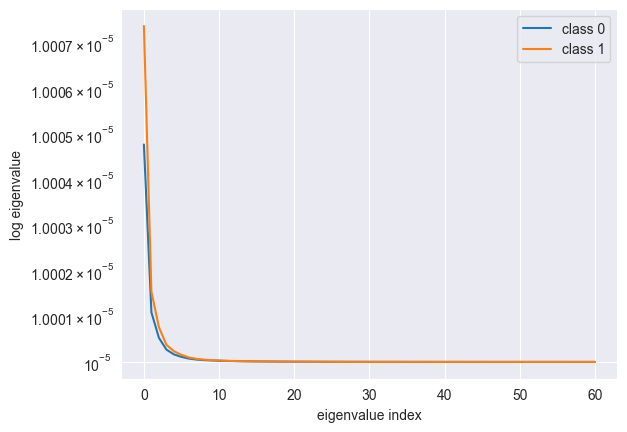

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# def eig_spectra(covs, y, title):
eigs_0 = np.array([np.sort(np.linalg.eigvalsh(C))[::-1] for C in covs[y == 0]])
eigs_1 = np.array([np.sort(np.linalg.eigvalsh(C))[::-1] for C in covs[y == 1]])

plt.figure()

plt.plot(eigs_0.mean(axis=0), label="class 0")
plt.plot(eigs_1.mean(axis=0), label="class 1")

plt.yscale("log")
plt.legend()
# plt.title(title)
plt.xlabel("eigenvalue index")
plt.ylabel("log eigenvalue")
plt.show()

In [45]:
import warnings
warnings.filterwarnings("ignore", message=".*logm result may be inaccurate.*")

In [46]:
from scipy.linalg import logm

def log_distances(covs):
    logs = np.array([logm(C) for C in covs])
    M = logs.mean(axis=0)

    dists = [np.linalg.norm(L - M, 'fro') for L in logs]
    return np.array(dists)

d0 = log_distances(covs[y == 0])
d1 = log_distances(covs[y == 1])

plt.hist(d0, bins=50, alpha=0.5, label="class 0")
plt.hist(d1, bins=50, alpha=0.5, label="class 1")
plt.legend()
plt.title("Log-Euclidean dispersion")
plt.show()

logm result may be inaccurate, approximate err = 2.306031685380218e-13
logm result may be inaccurate, approximate err = 2.3874953820282473e-13
logm result may be inaccurate, approximate err = 2.482166494452819e-13
logm result may be inaccurate, approximate err = 2.324274623172647e-13
logm result may be inaccurate, approximate err = 2.4752139837049477e-13
logm result may be inaccurate, approximate err = 2.367055783541192e-13
logm result may be inaccurate, approximate err = 2.4165447113046196e-13
logm result may be inaccurate, approximate err = 2.2245677497864232e-13
logm result may be inaccurate, approximate err = 2.2244304293619958e-13
logm result may be inaccurate, approximate err = 2.3146841183163056e-13
logm result may be inaccurate, approximate err = 2.797270098177554e-13
logm result may be inaccurate, approximate err = 2.3312444002684533e-13
logm result may be inaccurate, approximate err = 2.4218759867892307e-13
logm result may be inaccurate, approximate err = 2.7568553622125466e-

KeyboardInterrupt: 

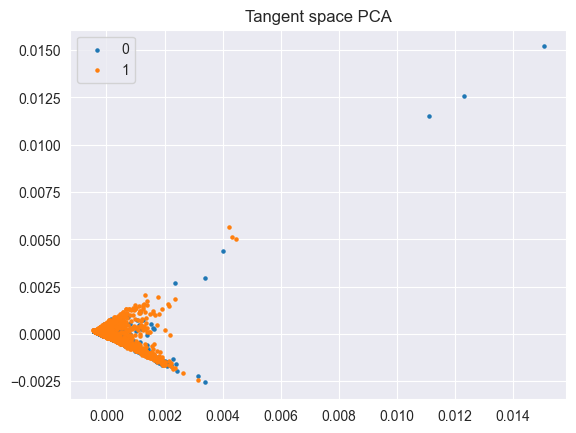

In [40]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X2 = pca.fit_transform(X_ts_train)

plt.scatter(X2[y_train==0,0], X2[y_train==0,1], s=5, label="0")
plt.scatter(X2[y_train==1,0], X2[y_train==1,1], s=5, label="1")
plt.legend()
plt.title("Tangent space PCA")
plt.show()

In [41]:
from scipy.spatial.distance import pdist, squareform

def riemann_dist(C1, C2):
    from scipy.linalg import logm
    return np.linalg.norm(logm(C1) - logm(C2), 'fro')

n = len(covs[:200])
D = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        D[i,j] = riemann_dist(covs[i], covs[j])

plt.imshow(D, cmap="hot")
plt.title("Pairwise Riemannian distances")
plt.colorbar()
plt.show()

logm result may be inaccurate, approximate err = 2.306031685380218e-13
logm result may be inaccurate, approximate err = 2.3874953820282473e-13
logm result may be inaccurate, approximate err = 2.482166494452819e-13
logm result may be inaccurate, approximate err = 2.324274623172647e-13
logm result may be inaccurate, approximate err = 2.4752139837049477e-13
logm result may be inaccurate, approximate err = 2.367055783541192e-13
logm result may be inaccurate, approximate err = 2.4165447113046196e-13
logm result may be inaccurate, approximate err = 2.2245677497864232e-13
logm result may be inaccurate, approximate err = 2.2244304293619958e-13
logm result may be inaccurate, approximate err = 2.3146841183163056e-13
logm result may be inaccurate, approximate err = 2.797270098177554e-13
logm result may be inaccurate, approximate err = 2.3312444002684533e-13
logm result may be inaccurate, approximate err = 2.4218759867892307e-13
logm result may be inaccurate, approximate err = 2.7568553622125466e-

KeyboardInterrupt: 

ValueError: 'c' argument must be a color, a sequence of colors, or a sequence of numbers, not array(['sub-13', 'sub-13', 'sub-13', ..., 'sub-49', 'sub-49', 'sub-49'],
      shape=(7500,), dtype='<U6')

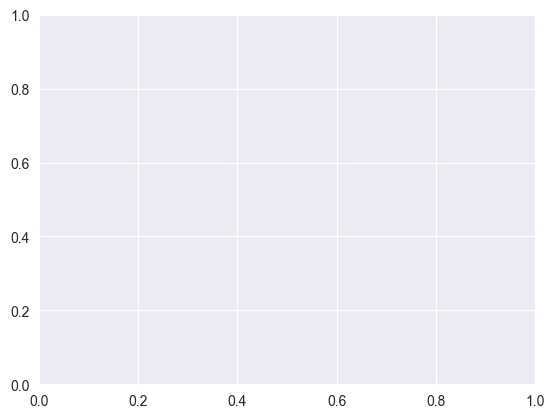

In [43]:
from sklearn.decomposition import PCA

X = np.array([C.flatten() for C in covs])

X2 = PCA(n_components=2).fit_transform(X)

plt.scatter(X2[:,0], X2[:,1], c=subjects, cmap="tab20", s=5)
plt.title("Subject/task drift in covariance space")
plt.colorbar()
plt.show()

# thing

In [47]:
import numpy as np
from scipy.linalg import fractional_matrix_power, svd
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier

# ============================================================
# CONFIG
# ============================================================

REG = 1e-5
CALIBRATION_RATIO = 0.3  # Paper uses a calibration subset from testing
VARIANCE_THRESHOLD = 0.999  # 99.9% as per paper

# ============================================================
# STABLE COVARIANCE
# ============================================================

def compute_covariance(w):
    w = w - np.mean(w, axis=1, keepdims=True)
    s = w.shape[1]
    C = (w @ w.T) / (s - 1)
    C += REG * np.eye(C.shape[0])
    return C

# ============================================================
# LOG-EUCLIDEAN GEOMETRY
# ============================================================

def log_euclidean(C):
    """Matrix logarithm for SPD matrix"""
    eigvals, eigvecs = np.linalg.eigh(C)
    eigvals = np.clip(eigvals, 1e-12, None)
    return eigvecs @ np.diag(np.log(eigvals)) @ eigvecs.T

def log_euclidean_mean(covs):
    """Log-Euclidean mean of SPD matrices"""
    logs = np.array([log_euclidean(C) for C in covs])
    mean_log = np.mean(logs, axis=0)

    # Exponentiate to return to SPD space
    eigvals, eigvecs = np.linalg.eigh(mean_log)
    eigvals = np.clip(eigvals, -1e12, None)  # Allow negative for exponentiation
    return eigvecs @ np.diag(np.exp(eigvals)) @ eigvecs.T

def tangent_space_projection(covs, reference):
    """
    Project SPD matrices to tangent space at reference (identity after whitening)
    Returns: matrices in tangent space (symmetric, not yet vectorized)
    """
    ref_inv_sqrt = fractional_matrix_power(reference, -0.5)

    projected = []
    for C in covs:
        # Recentre: C_rec = M^{-1/2} C M^{-1/2}
        C_rec = ref_inv_sqrt @ C @ ref_inv_sqrt
        # Tangent space projection at identity: log(C_rec)
        C_ts = log_euclidean(C_rec)
        # Ensure symmetry
        C_ts = (C_ts + C_ts.T) / 2
        projected.append(C_ts)

    return np.array(projected)

# ============================================================
# RESCALING (Distribution Matching)
# ============================================================

def frobenius_norm(X):
    """Frobenius norm for matrix or batch of matrices"""
    if X.ndim == 2:
        return np.sqrt(np.sum(X**2))
    else:
        return np.sqrt(np.sum(X.reshape(len(X), -1)**2, axis=1))

def rescale_to_unit_mean_norm(features):
    """
    Equation 6: ~C_SC = Ĉ_TS / ((1/t) * Σ||Ĉ_TS_n||)
    Normalizes average Frobenius norm to 1
    """
    norms = frobenius_norm(features)
    mean_norm = np.mean(norms)
    return features / (mean_norm + 1e-12)

# ============================================================
# CLASS-WISE ANCHOR POINTS (Equation 7-8)
# ============================================================

def class_wise_anchors(features, labels):
    """
    Compute anchor points per class (Equation 7)
    features: array of shape (n_trials, ch, ch) - still in matrix form
    """
    unique_classes = np.unique(labels)
    anchors = []

    for c in unique_classes:
        class_features = features[labels == c]
        # Mean in tangent space (still matrix form)
        anchor = np.mean(class_features, axis=0)
        anchors.append(anchor)

    # Concatenate along feature dimension (Equation 8)
    # Paper: flatten or concatenate? They form matrices by concatenation
    # For cross-product: we need 2D matrices, so vectorize each anchor
    anchors_vectorized = np.array([a.flatten() for a in anchors])

    return anchors_vectorized.T  # Shape: (n_features, n_classes)

# ============================================================
# ROTATION ALIGNMENT (Paper Version - Equations 9-11)
# ============================================================

def compute_rotation_matrix(anchors_train, anchors_calib, variance_threshold=0.999):
    """
    Compute rotation matrix R = Ũ @ Ṽ^T using SVD on cross-product matrix

    Equation 9: C_TC = C̄_train @ C̄_calib^T
    Equation 10: C_TC = U D V^T
    Truncate to retain 99.9% variance (or specified threshold)
    Equation 11: ~C_ROT_eval = Ũ @ Ṽ^T @ ~C_SC_eval
    """
    # Equation 9: Cross-product matrix
    C_TC = anchors_train @ anchors_calib.T

    # Equation 10: Singular Value Decomposition
    U, S, Vt = np.linalg.svd(C_TC, full_matrices=False)

    # Truncate based on variance explained
    var_exp = np.cumsum(S) / (np.sum(S) + 1e-12)
    n_components = np.searchsorted(var_exp, variance_threshold) + 1

    # Keep only top components (Ũ and Ṽ)
    U_trunc = U[:, :n_components]
    Vt_trunc = Vt[:n_components, :]

    # Rotation matrix R = Ũ @ Ṽ^T
    R = U_trunc @ Vt_trunc

    return R

def apply_rotation(features_matrix, rotation_matrix):
    """
    Apply rotation to evaluation features (Equation 11)
    features_matrix: shape (n_samples, n_features) - already vectorized/flattened
    rotation_matrix: shape (n_features, n_features)
    """
    # ~C_ROT_eval = R @ ~C_SC_eval
    return (rotation_matrix @ features_matrix.T).T

# ============================================================
# COMPLETE PS-ITSA PIPELINE
# ============================================================

def ps_itsa_pipeline(covs_train, covs_test, y_train, y_test,
                     calib_ratio=CALIBRATION_RATIO,
                     var_threshold=VARIANCE_THRESHOLD):
    """
    Complete PS-ITSA implementation following the paper's three steps:
    1. Recentering (Log-Euclidean mean + tangent space projection)
    2. Rescale (Distribution matching to unit mean norm)
    3. Rotation (Supervised alignment using calibration subset)
    """

    # ============================================================
    # STEP 1: RECENTERING (Log-Euclidean)
    # ============================================================
    print("Step 1: Recentering (Log-Euclidean)...")

    # 1a. Compute log-Euclidean centre M from training covariances
    M = log_euclidean_mean(covs_train)

    # 1b. Project all covariances to tangent space at M
    # This implements: Ĉ_TS = log(M^{-1/2} C M^{-1/2})
    C_train_ts = tangent_space_projection(covs_train, M)
    C_test_ts = tangent_space_projection(covs_test, M)

    # 1c. Combine training subjects (already done)

    # ============================================================
    # STEP 2: RESCALE (Distribution Matching)
    # ============================================================
    print("Step 2: Rescale (unit mean norm)...")

    # Equation 6: Rescale to set average norm = 1
    C_train_rescaled = rescale_to_unit_mean_norm(C_train_ts)
    C_test_rescaled = rescale_to_unit_mean_norm(C_test_ts)

    # ============================================================
    # STEP 3: ROTATION (Supervised Alignment)
    # ============================================================
    print("Step 3: Rotation alignment...")

    # 3a. Split testing into calibration (T₁) and evaluation (T₂)
    n_test = len(C_test_rescaled)
    n_calib = int(n_test * calib_ratio)

    # Random permutation for splitting (use fixed seed for reproducibility)
    np.random.seed(42)
    indices = np.random.permutation(n_test)
    calib_idx = indices[:n_calib]
    eval_idx = indices[n_calib:]

    C_calib = C_test_rescaled[calib_idx]
    C_eval = C_test_rescaled[eval_idx]
    y_calib = y_test[calib_idx]
    y_eval = y_test[eval_idx]

    # 3b-3c. Separate per class and compute anchor points (Equation 7)
    # Note: Anchors computed on RESCALED features (still matrix form)
    # For cross-product, we need to vectorize

    # Vectorize all features (flatten upper triangle or full matrix)
    # Paper appears to use full flattening based on diagram
    train_vec = C_train_rescaled.reshape(len(C_train_rescaled), -1)
    calib_vec = C_calib.reshape(len(C_calib), -1)

    # Compute anchor points per class (Equation 7) -> Equation 8
    anchors_train = class_wise_anchors(train_vec, y_train)
    anchors_calib = class_wise_anchors(calib_vec, y_calib)

    # 3d-3e. Compute rotation matrix from anchors
    R = compute_rotation_matrix(anchors_train, anchors_calib, var_threshold)

    # 3f. Align evaluation features (Equation 11)
    eval_vec = C_eval.reshape(len(C_eval), -1)
    eval_rotated = apply_rotation(eval_vec, R)

    # Also align training features (for model training, though paper may not require)
    train_rotated = apply_rotation(train_vec, R)

    print(f"  Rotation matrix shape: {R.shape}")
    print(f"  Calibration samples: {len(C_calib)}, Evaluation samples: {len(C_eval)}")

    return train_rotated, eval_rotated, y_train, y_eval

# ============================================================
# MODEL EVALUATION
# ============================================================

def evaluate_with_xgboost(X_train, X_test, y_train, y_test):
    """Train XGBoost and evaluate"""

    # Ensure real values and float64
    X_train = np.real(X_train).astype(np.float64)
    X_test = np.real(X_test).astype(np.float64)

    model = XGBClassifier(
        n_estimators=150,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        n_jobs=-1,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print("\n" + "="*50)
    print("CLASSIFICATION RESULTS")
    print("="*50)
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

    return model, y_pred, y_prob


covs_train = covs[train_mask]
covs_test = covs[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

# Run PS-ITSA pipeline
X_train, X_test, y_train_aligned, y_test_aligned = ps_itsa_pipeline(
    covs_train, covs_test, y_train, y_test,
    calib_ratio=0.3,
    var_threshold=0.999
)

# Evaluate
evaluate_with_xgboost(X_train, X_test, y_train_aligned, y_test_aligned)

Step 1: Recentering (Log-Euclidean)...
Step 2: Rescale (unit mean norm)...
Step 3: Rotation alignment...
  Rotation matrix shape: (3721, 3721)
  Calibration samples: 675, Evaluation samples: 1575

CLASSIFICATION RESULTS
              precision    recall  f1-score   support

           0       0.51      0.33      0.40       642
           1       0.63      0.79      0.70       933

    accuracy                           0.60      1575
   macro avg       0.57      0.56      0.55      1575
weighted avg       0.58      0.60      0.58      1575

ROC-AUC: 0.6360


(XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.8, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.03, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=4, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=150, n_jobs=-1,
               num_parallel_tree=None, ...),
 array([0, 1, 1, ..., 1, 1, 1], shape=(1575,)),
 array([0.49063188, 0.5375534 , 0.74722403, ..., 0.6443809 , 0.7511993 ,
        0.7395006 ], shape=(1575,), dtype=float32))

# another

In [48]:
import numpy as np
from scipy.linalg import fractional_matrix_power
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier

# ============================================================
# CONFIG
# ============================================================

REG = 1e-5
CALIBRATION_RATIO = 0.3
VARIANCE_THRESHOLD = 0.999  # 99.9% as per paper

# ============================================================
# COVARIANCE ESTIMATION
# ============================================================

def compute_covariance(w):
    """Compute regularized covariance matrix from window"""
    w = w - np.mean(w, axis=1, keepdims=True)
    s = w.shape[1]
    C = (w @ w.T) / (s - 1)
    C += REG * np.eye(C.shape[0])
    return C

# ============================================================
# LOG-EUCLIDEAN GEOMETRY
# ============================================================

def log_euclidean(C):
    """Matrix logarithm for SPD matrix"""
    eigvals, eigvecs = np.linalg.eigh(C)
    eigvals = np.clip(eigvals, 1e-12, None)
    return eigvecs @ np.diag(np.log(eigvals)) @ eigvecs.T

def log_euclidean_mean(covs):
    """Log-Euclidean mean of SPD matrices"""
    logs = np.array([log_euclidean(C) for C in covs])
    mean_log = np.mean(logs, axis=0)

    # Exponentiate to return to SPD space
    eigvals, eigvecs = np.linalg.eigh(mean_log)
    eigvals = np.clip(eigvals, -1e12, None)
    return eigvecs @ np.diag(np.exp(eigvals)) @ eigvecs.T

def tangent_space_projection(covs, reference):
    """
    Project SPD matrices to tangent space at identity after whitening.
    Returns: matrices in tangent space (symmetric, still matrix form)
    """
    ref_inv_sqrt = fractional_matrix_power(reference, -0.5)

    projected = []
    for C in covs:
        # Recentre: C_rec = M^{-1/2} C M^{-1/2}
        C_rec = ref_inv_sqrt @ C @ ref_inv_sqrt
        # Tangent space projection at identity: log(C_rec)
        C_ts = log_euclidean(C_rec)
        # Ensure symmetry (numerical stability)
        C_ts = (C_ts + C_ts.T) / 2
        projected.append(C_ts)

    return np.array(projected)

# ============================================================
# RESCALING (Distribution Matching)
# ============================================================

def frobenius_norm_batch(matrices):
    """Compute Frobenius norm for batch of matrices"""
    return np.sqrt(np.sum(matrices.reshape(len(matrices), -1)**2, axis=1))

def rescale_to_unit_mean_norm(features):
    """
    Equation 6: ~C_SC = Ĉ_TS / ((1/t) * Σ||Ĉ_TS_n||)
    Normalizes average Frobenius norm to 1
    """
    norms = frobenius_norm_batch(features)
    mean_norm = np.mean(norms)
    return features / (mean_norm + 1e-12)

# ============================================================
# CLASS-WISE ANCHOR POINTS (CHANNEL SPACE - FIXED)
# ============================================================

def class_wise_anchors_matrix(features, labels):
    """
    Return anchors as matrices (not flattened).
    Following paper: each anchor is e×e, concatenated horizontally.

    features: array of shape (n_trials, ch, ch) - still in matrix form
    labels: array of shape (n_trials,)

    Returns: anchors matrix of shape (ch, ch * K) where K = number of classes
    """
    unique_classes = np.unique(labels)
    anchors = []

    for c in unique_classes:
        class_features = features[labels == c]  # Shape: (n_class, ch, ch)
        anchor = np.mean(class_features, axis=0)  # Shape: (ch, ch)
        anchors.append(anchor)

    # Concatenate along columns: (ch, ch*K)
    return np.hstack(anchors)

# ============================================================
# ROTATION ALIGNMENT (CHANNEL SPACE - FIXED)
# ============================================================

def compute_rotation_matrix_channel_space(anchors_train, anchors_calib, variance_threshold=0.999):
    """
    Compute rotation matrix R = Ũ @ Ṽ^T using SVD on cross-product matrix.
    Operates in CHANNEL space (ch × ch), NOT feature space.

    anchors_train: shape (ch, ch*K)
    anchors_calib: shape (ch, ch*K)

    Returns: R of shape (ch, ch)
    """
    # Equation 9: Cross-product matrix
    C_TC = anchors_train @ anchors_calib.T  # Shape: (ch, ch)

    # Equation 10: Singular Value Decomposition
    U, S, Vt = np.linalg.svd(C_TC, full_matrices=False)

    # Truncate based on variance explained (optional, but in paper)
    var_exp = np.cumsum(S) / (np.sum(S) + 1e-12)
    n_components = np.searchsorted(var_exp, variance_threshold) + 1

    # Keep only top components (Ũ and Ṽ)
    U_trunc = U[:, :n_components]
    Vt_trunc = Vt[:n_components, :]

    # Rotation matrix R = Ũ @ Ṽ^T
    R = U_trunc @ Vt_trunc

    return R

def apply_rotation_to_matrices(matrices, rotation_matrix):
    """
    Apply rotation to each matrix: R @ X
    matrices: shape (n_trials, ch, ch)
    rotation_matrix: shape (ch, ch)

    Returns: rotated matrices of shape (n_trials, ch, ch)
    """
    return np.array([rotation_matrix @ X for X in matrices])

# ============================================================
# COMPLETE PS-ITSA PIPELINE (CORRECTED)
# ============================================================

def ps_itsa_pipeline_corrected(covs_train, covs_test, y_train, y_test,
                                calib_ratio=CALIBRATION_RATIO,
                                var_threshold=VARIANCE_THRESHOLD):
    """
    Complete PS-ITSA implementation with corrected channel-space rotation.

    Steps:
    1. Recentering (Log-Euclidean mean + tangent space projection)
    2. Rescale (Distribution matching to unit mean norm)
    3. Rotation (Supervised alignment using calibration subset - CHANNEL SPACE)
    """

    n_channels = covs_train[0].shape[0]
    print(f"Number of channels: {n_channels}")

    # ============================================================
    # STEP 1: RECENTERING (Log-Euclidean)
    # ============================================================
    print("\n[Step 1] Recentering (Log-Euclidean)...")

    # 1a. Compute log-Euclidean centre M from training covariances
    M = log_euclidean_mean(covs_train)

    # 1b. Project all covariances to tangent space at M
    # Returns matrices of shape (n_trials, ch, ch) - NOT flattened yet
    C_train_ts = tangent_space_projection(covs_train, M)
    C_test_ts = tangent_space_projection(covs_test, M)

    print(f"  Training tangent space matrices: {C_train_ts.shape}")
    print(f"  Testing tangent space matrices: {C_test_ts.shape}")

    # ============================================================
    # STEP 2: RESCALE (Distribution Matching)
    # ============================================================
    print("\n[Step 2] Rescale (unit mean norm)...")

    # Equation 6: Rescale to set average norm = 1
    C_train_rescaled = rescale_to_unit_mean_norm(C_train_ts)
    C_test_rescaled = rescale_to_unit_mean_norm(C_test_ts)

    # ============================================================
    # STEP 3: ROTATION (Supervised Alignment - CHANNEL SPACE)
    # ============================================================
    print("\n[Step 3] Rotation alignment (channel space)...")

    # 3a. Split testing into calibration (T₁) and evaluation (T₂)
    n_test = len(C_test_rescaled)
    n_calib = int(n_test * calib_ratio)

    np.random.seed(42)
    indices = np.random.permutation(n_test)
    calib_idx = indices[:n_calib]
    eval_idx = indices[n_calib:]

    C_calib = C_test_rescaled[calib_idx]
    C_eval = C_test_rescaled[eval_idx]
    y_calib = y_test[calib_idx]
    y_eval = y_test[eval_idx]

    print(f"  Calibration samples: {len(C_calib)}")
    print(f"  Evaluation samples: {len(C_eval)}")

    # 3b-3c. Compute anchor points (still matrix form - NOT flattened)
    # Equation 7-8: Class-wise means concatenated
    anchors_train = class_wise_anchors_matrix(C_train_rescaled, y_train)  # (ch, ch*K)
    anchors_calib = class_wise_anchors_matrix(C_calib, y_calib)           # (ch, ch*K)

    print(f"  Anchors train shape: {anchors_train.shape}")
    print(f"  Anchors calib shape: {anchors_calib.shape}")

    # 3d-3e. Compute rotation matrix from anchors (channel space!)
    R = compute_rotation_matrix_channel_space(anchors_train, anchors_calib, var_threshold)

    print(f"  Rotation matrix shape: {R.shape}")  # Should be (ch, ch)

    # 3f. Apply rotation to evaluation matrices (BEFORE flattening!)
    C_eval_rotated = apply_rotation_to_matrices(C_eval, R)

    # Also rotate training matrices (optional, for consistent feature space)
    C_train_rotated = apply_rotation_to_matrices(C_train_rescaled, R)

    # NOW flatten for classifier (upper triangle or full matrix)
    # Paper diagram shows "flattened rectangles"
    X_train = C_train_rotated.reshape(len(C_train_rotated), -1)
    X_test = C_eval_rotated.reshape(len(C_eval_rotated), -1)

    print(f"  Flattened training features: {X_train.shape}")
    print(f"  Flattened testing features: {X_test.shape}")

    return X_train, X_test, y_train, y_eval

# ============================================================
# MODEL EVALUATION
# ============================================================

def evaluate_with_xgboost(X_train, X_test, y_train, y_test):
    """Train XGBoost and evaluate"""

    X_train = np.real(X_train).astype(np.float64)
    X_test = np.real(X_test).astype(np.float64)

    model = XGBClassifier(
        n_estimators=150,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        n_jobs=-1,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print("\n" + "="*60)
    print("CLASSIFICATION RESULTS (Corrected PS-ITSA)")
    print("="*60)
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

    return model, y_pred, y_prob

covs_train = covs[train_mask]
covs_test = covs[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

print(f"Training samples: {len(covs_train)}")
print(f"Testing samples: {len(covs_test)}")
print(f"Number of channels: {covs_train[0].shape[0]}")
print(f"Classes: {np.unique(y_train)}")

# Run corrected PS-ITSA pipeline
X_train, X_test, y_train_aligned, y_test_aligned = ps_itsa_pipeline_corrected(
    covs_train, covs_test, y_train, y_test,
    calib_ratio=0.3,
    var_threshold=0.999
)

# Evaluate
evaluate_with_xgboost(X_train, X_test, y_train_aligned, y_test_aligned)

Training samples: 5250
Testing samples: 2250
Number of channels: 61
Classes: [0 1]
Number of channels: 61

[Step 1] Recentering (Log-Euclidean)...
  Training tangent space matrices: (5250, 61, 61)
  Testing tangent space matrices: (2250, 61, 61)

[Step 2] Rescale (unit mean norm)...

[Step 3] Rotation alignment (channel space)...
  Calibration samples: 675
  Evaluation samples: 1575
  Anchors train shape: (61, 122)
  Anchors calib shape: (61, 122)
  Rotation matrix shape: (61, 61)
  Flattened training features: (5250, 3721)
  Flattened testing features: (1575, 3721)

CLASSIFICATION RESULTS (Corrected PS-ITSA)
              precision    recall  f1-score   support

           0       0.53      0.14      0.22       642
           1       0.61      0.92      0.73       933

    accuracy                           0.60      1575
   macro avg       0.57      0.53      0.47      1575
weighted avg       0.57      0.60      0.52      1575

ROC-AUC: 0.5805


(XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.8, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.03, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=4, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=150, n_jobs=-1,
               num_parallel_tree=None, ...),
 array([1, 1, 1, ..., 1, 1, 1], shape=(1575,)),
 array([0.68266636, 0.70196724, 0.78444254, ..., 0.7566888 , 0.78368497,
        0.7739545 ], shape=(1575,), dtype=float32))

# with hjorth, another (not paper-like)

In [49]:
import numpy as np
import mne

from scipy.signal import welch
from scipy.stats import entropy
from itertools import combinations

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.covariance import LedoitWolf

from xgboost import XGBClassifier

from pyriemann.utils.mean import mean_covariance
from pyriemann.tangentspace import TangentSpace
from scipy.linalg import fractional_matrix_power


TARGET_SFREQ = 125
WINDOW_SEC = 2.0
WINDOW_LEN = int(WINDOW_SEC * TARGET_SFREQ)

REG = 1e-5

# ============================================================
# COVARIANCE COMPUTATION
# ============================================================

def compute_covariance(w):
    """Compute regularized covariance matrix from window"""
    w = w - np.mean(w, axis=1, keepdims=True)
    s = w.shape[1]
    C = (w @ w.T) / (s - 1)
    C += REG * np.eye(C.shape[0])
    return C

# ============================================================
# SIGNAL LOADING
# ============================================================

def load_signal_all_channels(file):
    try:
        raw = mne.io.read_raw_brainvision(file, preload=True, verbose=False)

        if raw.info["bads"]:
            raw.drop_channels(raw.info["bads"])

        raw.notch_filter(50, verbose=False)
        raw.filter(1, 40, verbose=False)
        raw.resample(TARGET_SFREQ)

        data = raw.get_data()

        if not np.all(np.isfinite(data)):
            return None, None

        return data, raw.ch_names

    except:
        return None, None

# ============================================================
# HJORTH FEATURES (YOUR ORIGINAL FUNCTIONS)
# ============================================================

def hjorth_activity(x):
    return np.var(x)

def hjorth_mobility(x):
    v = np.var(x)
    return np.sqrt(np.var(np.diff(x)) / (v + 1e-12))

def hjorth_complexity(x):
    m = hjorth_mobility(x)
    return hjorth_mobility(np.diff(x)) / (m + 1e-12)

def extract_features_window(data, ch_names):
    """
    Extract Hjorth parameters for all channels in a window.
    Returns dictionary of features.
    """
    feats = {}

    for i, ch in enumerate(ch_names):
        x = data[i]

        # Original Hjorth parameters
        feats[f"{ch}_a"] = hjorth_activity(x)      # Activity
        feats[f"{ch}_m"] = hjorth_mobility(x)      # Mobility
        feats[f"{ch}_c"] = hjorth_complexity(x)    # Complexity

        # Log transformations (helps with skewed distributions)
        feats[f"{ch}_log_a"] = np.log(feats[f"{ch}_a"] + 1e-12)
        feats[f"{ch}_log_m"] = np.log(feats[f"{ch}_m"] + 1e-12)

    return feats

# ============================================================
# MAIN DATA COLLECTION
# ============================================================

all_feats = []      # Hjorth features
all_covs = []       # Covariance matrices
all_labels = []     # Labels
all_subjects = []   # Subject IDs

valid_subjects = sorted(set(rest_files.keys()) & set(task_files.keys()))

print("Processing subjects...")
for subj_idx, subj in enumerate(valid_subjects):
    print(f"  Subject {subj_idx+1}/{len(valid_subjects)}: {subj}")

    for label, file_list in [(0, rest_files[subj]), (1, task_files[subj])]:
        class_name = "Rest" if label == 0 else "Task"

        for f in file_list:
            data, ch_names = load_signal_all_channels(f)
            if data is None:
                print(f"    Failed to load: {f}")
                continue

            n_windows = data.shape[1] // WINDOW_LEN
            print(f"    {class_name}: {n_windows} windows from {f.split('/')[-1]}")

            for i in range(n_windows):
                w = data[:, i*WINDOW_LEN:(i+1)*WINDOW_LEN]

                # Skip if any channel is silent
                if np.any(np.std(w, axis=1) < 1e-10):
                    continue

                # Extract Hjorth features
                feats = extract_features_window(w, ch_names)
                vals = np.array(list(feats.values()))

                if not np.all(np.isfinite(vals)):
                    continue

                # Compute covariance matrix
                C = compute_covariance(w)

                if C.ndim != 2 or C.shape[0] != C.shape[1]:
                    continue

                # Store everything
                all_feats.append(vals)
                all_covs.append(C)
                all_labels.append(label)
                all_subjects.append(subj)

# Convert to numpy arrays
X_feats = np.array(all_feats)     # Hjorth features
covs = np.array(all_covs)          # Covariance matrices
y = np.array(all_labels)           # Labels
subjects = np.array(all_subjects)  # Subject IDs

print(f"\nTotal samples collected: {len(y)}")
print(f"  Class 0 (Rest): {np.sum(y == 0)}")
print(f"  Class 1 (Task): {np.sum(y == 1)}")
print(f"  Number of channels: {covs[0].shape[0]}")
print(f"  Hjorth features per window: {X_feats.shape[1]}")

# ============================================================
# SUBJECT SPLIT (70/30 subject-wise)
# ============================================================

unique_subjects = np.unique(subjects)
np.random.seed(42)

n_train_subjects = int(0.7 * len(unique_subjects))
train_subjects = np.random.choice(unique_subjects, n_train_subjects, replace=False)
test_subjects = np.array([s for s in unique_subjects if s not in train_subjects])

train_mask = np.isin(subjects, train_subjects)
test_mask = np.isin(subjects, test_subjects)

print(f"\nSubject split:")
print(f"  Training subjects ({len(train_subjects)}): {train_subjects}")
print(f"  Testing subjects ({len(test_subjects)}): {test_subjects}")
print(f"  Training samples: {np.sum(train_mask)}")
print(f"  Testing samples: {np.sum(test_mask)}")

# ============================================================
# PREPARE DATA FOR PIPELINE
# ============================================================

covs_train = covs[train_mask]
covs_test = covs[test_mask]
X_feats_train = X_feats[train_mask]
X_feats_test = X_feats[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

# ============================================================
# RIEMANNIAN PIPELINE (YOUR BETTER APPROACH)
# ============================================================

print("\n" + "="*60)
print("RIEMANNIAN PIPELINE WITH HJORTH FEATURES")
print("="*60)

# ---- Step 1: Riemannian mean and whitening ----
print("\n[Step 1] Computing Riemannian mean...")
M = mean_covariance(covs_train, metric='riemann')

def whiten(C, M):
    M_inv_sqrt = fractional_matrix_power(M, -0.5)
    return M_inv_sqrt @ C @ M_inv_sqrt

print("  Whitening covariance matrices...")
covs_train_w = np.array([whiten(C, M) for C in covs_train])
covs_test_w = np.array([whiten(C, M) for C in covs_test])

# ---- Step 2: Tangent space projection ----
print("\n[Step 2] Projecting to tangent space...")
ts = TangentSpace(metric='riemann')
ts.fit(covs_train_w)

X_ts_train = ts.transform(covs_train_w)
X_ts_test = ts.transform(covs_test_w)

print(f"  Tangent space features: {X_ts_train.shape[1]}")

# ---- Step 3: Standardize Hjorth features ----
print("\n[Step 3] Standardizing Hjorth features...")
scaler = StandardScaler()
X_feats_train_scaled = scaler.fit_transform(X_feats_train)
X_feats_test_scaled = scaler.transform(X_feats_test)

print(f"  Hjorth features: {X_feats_train_scaled.shape[1]}")

# ---- Step 4: Fuse features ----
print("\n[Step 4] Fusing Riemannian + Hjorth features...")
X_train = np.concatenate([X_feats_train_scaled, X_ts_train], axis=1)
X_test = np.concatenate([X_feats_test_scaled, X_ts_test], axis=1)

print(f"  Total features: {X_train.shape[1]}")

# ---- Step 5: Train XGBoost ----
print("\n[Step 5] Training XGBoost classifier...")
model = XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

# ---- Step 6: Evaluate ----
print("\n[Step 6] Evaluating on test set...")
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\n" + "="*60)
print("CLASSIFICATION RESULTS")
print("="*60)
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

Processing subjects...
  Subject 1/10: sub-13
    Rest: 150 windows from sub-13_ses-session1_task-eyesclosed_eeg.vhdr
    Rest: 150 windows from sub-13_ses-session1_task-eyesopen_eeg.vhdr
    Task: 150 windows from sub-13_ses-session1_task-memory_eeg.vhdr
    Task: 150 windows from sub-13_ses-session1_task-music_eeg.vhdr
    Task: 150 windows from sub-13_ses-session1_task-mathematic_eeg.vhdr
  Subject 2/10: sub-14
    Rest: 150 windows from sub-14_ses-session1_task-eyesclosed_eeg.vhdr
    Rest: 150 windows from sub-14_ses-session1_task-eyesopen_eeg.vhdr
    Task: 150 windows from sub-14_ses-session1_task-memory_eeg.vhdr
    Task: 150 windows from sub-14_ses-session1_task-mathematic_eeg.vhdr
    Task: 150 windows from sub-14_ses-session1_task-music_eeg.vhdr
  Subject 3/10: sub-15
    Rest: 150 windows from sub-15_ses-session1_task-eyesclosed_eeg.vhdr
    Rest: 150 windows from sub-15_ses-session1_task-eyesopen_eeg.vhdr
    Task: 150 windows from sub-15_ses-session1_task-music_eeg.vhdr
 

In [ ]:
print("\n" + "="*60)
print("TOP 10 FEATURE IMPORTANCES")
print("="*60)

feature_names = (
    [f"Hjorth_{i}" for i in range(X_feats_train_scaled.shape[1])] +
    [f"Riemannian_{i}" for i in range(X_ts_train.shape[1])]
)

importances = model.feature_importances_
top_idx = np.argsort(importances)[-10:][::-1]

for i, idx in enumerate(top_idx):
    print(f"  {i+1}. {feature_names[idx]}: {importances[idx]:.4f}")

# hjorth, paper like

In [51]:
import numpy as np
from scipy.linalg import fractional_matrix_power
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier

# ============================================================
# CONFIG
# ============================================================

REG = 1e-5
CALIBRATION_RATIO = 0.3
VARIANCE_THRESHOLD = 0.999  # 99.9% as per paper

# ============================================================
# COVARIANCE ESTIMATION
# ============================================================

def compute_covariance(w):
    """Compute regularized covariance matrix from window"""
    w = w - np.mean(w, axis=1, keepdims=True)
    s = w.shape[1]
    C = (w @ w.T) / (s - 1)
    C += REG * np.eye(C.shape[0])
    return C

# ============================================================
# HJORTH FEATURES (TIME-DOMAIN)
# ============================================================

def hjorth_activity(x):
    return np.var(x)

def hjorth_mobility(x):
    v = np.var(x)
    return np.sqrt(np.var(np.diff(x)) / (v + 1e-12))

def hjorth_complexity(x):
    m = hjorth_mobility(x)
    return hjorth_mobility(np.diff(x)) / (m + 1e-12)

def extract_hjorth_features(data, ch_names):
    """
    Extract Hjorth parameters for all channels.
    Returns: 1D array of features
    """
    feats = {}
    for i, ch in enumerate(ch_names):
        x = data[i]

        # Original Hjorth parameters
        feats[f"{ch}_a"] = hjorth_activity(x)
        feats[f"{ch}_m"] = hjorth_mobility(x)
        feats[f"{ch}_c"] = hjorth_complexity(x)

        # Log transforms (helps with skewed distributions)
        feats[f"{ch}_log_a"] = np.log(feats[f"{ch}_a"] + 1e-12)
        feats[f"{ch}_log_m"] = np.log(feats[f"{ch}_m"] + 1e-12)

    return np.array(list(feats.values()))

# ============================================================
# LOG-EUCLIDEAN GEOMETRY (Paper's method)
# ============================================================

def log_euclidean(C):
    """Matrix logarithm for SPD matrix"""
    eigvals, eigvecs = np.linalg.eigh(C)
    eigvals = np.clip(eigvals, 1e-12, None)
    return eigvecs @ np.diag(np.log(eigvals)) @ eigvecs.T

def log_euclidean_mean(covs):
    """Log-Euclidean mean of SPD matrices"""
    logs = np.array([log_euclidean(C) for C in covs])
    mean_log = np.mean(logs, axis=0)

    # Exponentiate to return to SPD space
    eigvals, eigvecs = np.linalg.eigh(mean_log)
    eigvals = np.clip(eigvals, -1e12, None)
    return eigvecs @ np.diag(np.exp(eigvals)) @ eigvecs.T

def tangent_space_projection(covs, reference):
    """
    Project SPD matrices to tangent space at identity after whitening.
    Returns: matrices in tangent space (symmetric, still matrix form)
    """
    ref_inv_sqrt = fractional_matrix_power(reference, -0.5)

    projected = []
    for C in covs:
        # Recentre: C_rec = M^{-1/2} C M^{-1/2}
        C_rec = ref_inv_sqrt @ C @ ref_inv_sqrt
        # Tangent space projection at identity: log(C_rec)
        C_ts = log_euclidean(C_rec)
        # Ensure symmetry (numerical stability)
        C_ts = (C_ts + C_ts.T) / 2
        projected.append(C_ts)

    return np.array(projected)

# ============================================================
# RESCALING (Distribution Matching)
# ============================================================

def rescale_to_unit_mean_norm(features):
    """
    Equation 6: ~C_SC = Ĉ_TS / ((1/t) * Σ||Ĉ_TS_n||)
    Normalizes average Frobenius norm to 1
    """
    norms = np.sqrt(np.sum(features.reshape(len(features), -1)**2, axis=1))
    mean_norm = np.mean(norms)
    return features / (mean_norm + 1e-12)

# ============================================================
# CLASS-WISE ANCHOR POINTS (CHANNEL SPACE - CORRECTED)
# ============================================================

def class_wise_anchors_matrix(features, labels):
    """
    Return anchors as matrices (not flattened).
    Following paper: each anchor is e×e, concatenated horizontally.

    features: array of shape (n_trials, ch, ch) - still in matrix form
    labels: array of shape (n_trials,)

    Returns: anchors matrix of shape (ch, ch * K) where K = number of classes
    """
    unique_classes = np.unique(labels)
    anchors = []

    for c in unique_classes:
        class_features = features[labels == c]  # Shape: (n_class, ch, ch)
        anchor = np.mean(class_features, axis=0)  # Shape: (ch, ch)
        anchors.append(anchor)

    # Concatenate along columns: (ch, ch*K)
    return np.hstack(anchors)

def compute_rotation_matrix_channel_space(anchors_train, anchors_calib, variance_threshold=0.999):
    """
    Compute rotation matrix R = Ũ @ Ṽ^T using SVD on cross-product matrix.
    Operates in CHANNEL space (ch × ch), NOT feature space.

    anchors_train: shape (ch, ch*K)
    anchors_calib: shape (ch, ch*K)

    Returns: R of shape (ch, ch)
    """
    # Equation 9: Cross-product matrix
    C_TC = anchors_train @ anchors_calib.T  # Shape: (ch, ch)

    # Equation 10: Singular Value Decomposition
    U, S, Vt = np.linalg.svd(C_TC, full_matrices=False)

    # Truncate based on variance explained (99.9% as per paper)
    var_exp = np.cumsum(S) / (np.sum(S) + 1e-12)
    n_components = np.searchsorted(var_exp, variance_threshold) + 1

    # Keep only top components (Ũ and Ṽ)
    U_trunc = U[:, :n_components]
    Vt_trunc = Vt[:n_components, :]

    # Rotation matrix R = Ũ @ Ṽ^T
    R = U_trunc @ Vt_trunc

    return R

def apply_rotation_to_matrices(matrices, rotation_matrix):
    """
    Apply rotation to each matrix: R @ X
    matrices: shape (n_trials, ch, ch)
    rotation_matrix: shape (ch, ch)

    Returns: rotated matrices of shape (n_trials, ch, ch)
    """
    return np.array([rotation_matrix @ X for X in matrices])

# ============================================================
# COMPLETE PS-ITSA PIPELINE WITH HJORTH FEATURES
# ============================================================

# ============================================================
# COMPLETE PS-ITSA PIPELINE WITH HJORTH FEATURES (FIXED)
# ============================================================

def ps_itsa_with_hjorth(covs_train, covs_test,
                         hjorth_train, hjorth_test,
                         y_train, y_test,
                         calib_ratio=CALIBRATION_RATIO,
                         var_threshold=VARIANCE_THRESHOLD):
    """
    Complete PS-ITSA implementation with Hjorth time-domain features.

    Steps:
    1. Recentering (Log-Euclidean mean + tangent space projection)
    2. Rescale (Distribution matching to unit mean norm)
    3. Rotation (Supervised alignment using calibration subset - CHANNEL SPACE)
    4. Fuse with Hjorth features
    5. Classify
    """

    n_channels = covs_train[0].shape[0]
    print(f"\n{'='*60}")
    print(f"PS-ITSA + HJORTH PIPELINE (Paper-like)")
    print(f"{'='*60}")
    print(f"Number of channels: {n_channels}")
    print(f"Training samples: {len(covs_train)}")
    print(f"Testing samples: {len(covs_test)}")

    # ============================================================
    # STEP 1: RECENTERING (Log-Euclidean)
    # ============================================================
    print("\n[Step 1] Recentering (Log-Euclidean)...")

    # 1a. Compute log-Euclidean centre M from training covariances
    M = log_euclidean_mean(covs_train)

    # 1b. Project all covariances to tangent space at M
    C_train_ts = tangent_space_projection(covs_train, M)
    C_test_ts = tangent_space_projection(covs_test, M)

    print(f"  Training tangent space matrices: {C_train_ts.shape}")
    print(f"  Testing tangent space matrices: {C_test_ts.shape}")

    # ============================================================
    # STEP 2: RESCALE (Distribution Matching)
    # ============================================================
    print("\n[Step 2] Rescale (unit mean norm)...")

    C_train_rescaled = rescale_to_unit_mean_norm(C_train_ts)
    C_test_rescaled = rescale_to_unit_mean_norm(C_test_ts)

    # ============================================================
    # STEP 3: ROTATION (Supervised Alignment - CHANNEL SPACE)
    # ============================================================
    print("\n[Step 3] Rotation alignment (channel space)...")

    # 3a. Split testing into calibration (T₁) and evaluation (T₂)
    n_test = len(C_test_rescaled)
    n_calib = int(n_test * calib_ratio)

    np.random.seed(42)
    indices = np.random.permutation(n_test)
    calib_idx = indices[:n_calib]
    eval_idx = indices[n_calib:]

    C_calib = C_test_rescaled[calib_idx]
    C_eval = C_test_rescaled[eval_idx]
    y_calib = y_test[calib_idx]
    y_eval = y_test[eval_idx]

    # Also split Hjorth features to match indices
    hjorth_calib = hjorth_test[calib_idx]
    hjorth_eval = hjorth_test[eval_idx]

    print(f"  Calibration samples (T₁): {len(C_calib)}")
    print(f"  Evaluation samples (T₂): {len(C_eval)}")

    # 3b-3c. Compute anchor points (matrix form - NOT flattened)
    anchors_train = class_wise_anchors_matrix(C_train_rescaled, y_train)  # (ch, ch*K)
    anchors_calib = class_wise_anchors_matrix(C_calib, y_calib)           # (ch, ch*K)

    print(f"  Anchors train shape: {anchors_train.shape}")
    print(f"  Anchors calib shape: {anchors_calib.shape}")

    # 3d-3e. Compute rotation matrix from anchors (channel space!)
    R = compute_rotation_matrix_channel_space(anchors_train, anchors_calib, var_threshold)

    print(f"  Rotation matrix shape: {R.shape}")  # Should be (ch, ch)

    # 3f. Apply rotation to evaluation matrices (BEFORE flattening!)
    C_eval_rotated = apply_rotation_to_matrices(C_eval, R)

    # Also rotate training matrices (for consistent feature space)
    C_train_rotated = apply_rotation_to_matrices(C_train_rescaled, R)

    # Flatten covariance features for classifier
    X_cov_train = C_train_rotated.reshape(len(C_train_rotated), -1)
    X_cov_eval = C_eval_rotated.reshape(len(C_eval_rotated), -1)

    print(f"  Flattened covariance features: {X_cov_train.shape[1]}")

    # ============================================================
    # STEP 4: FUSE WITH HJORTH TIME-DOMAIN FEATURES
    # ============================================================
    print("\n[Step 4] Fusing Hjorth time-domain features...")

    # Standardize Hjorth features using training data only
    scaler_hjorth = StandardScaler()
    hjorth_train_scaled = scaler_hjorth.fit_transform(hjorth_train)  # FIT on training
    hjorth_calib_scaled = scaler_hjorth.transform(hjorth_calib)      # TRANSFORM calibration
    hjorth_eval_scaled = scaler_hjorth.transform(hjorth_eval)        # TRANSFORM evaluation

    # For training: use ALL training Hjorth features (already scaled)
    # For testing: use evaluation Hjorth features (matched to eval indices)
    X_train = np.concatenate([X_cov_train, hjorth_train_scaled], axis=1)
    X_test = np.concatenate([X_cov_eval, hjorth_eval_scaled], axis=1)

    print(f"  Hjorth features: {hjorth_train_scaled.shape[1]}")
    print(f"  Total features: {X_train.shape[1]}")

    return X_train, X_test, y_train, y_eval

# ============================================================
# MODEL EVALUATION
# ============================================================
def evaluate_with_xgboost(X_train, X_test, y_train, y_test, n_hjorth_features=None):
    """Train XGBoost and evaluate with feature importance breakdown"""

    X_train = np.real(X_train).astype(np.float64)
    X_test = np.real(X_test).astype(np.float64)

    model = XGBClassifier(
        n_estimators=150,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        n_jobs=-1,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print("\n" + "="*60)
    print("CLASSIFICATION RESULTS (PS-ITSA + Hjorth)")
    print("="*60)
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

    # Feature importance breakdown
    print("\n" + "-"*40)
    print("FEATURE IMPORTANCE ANALYSIS")
    print("-"*40)

    importances = model.feature_importances_

    if n_hjorth_features is not None:
        # Split covariance vs Hjorth features
        n_cov_features = X_train.shape[1] - n_hjorth_features
        cov_importance = np.mean(importances[:n_cov_features])
        hjorth_importance = np.mean(importances[n_cov_features:])

        print(f"\nFeature type summary:")
        print(f"  Covariance features ({n_cov_features} features): {cov_importance:.4f} average importance")
        print(f"  Hjorth features ({n_hjorth_features} features): {hjorth_importance:.4f} average importance")
        print(f"  Ratio (Hjorth/Cov): {hjorth_importance/cov_importance:.2f}x")

    # Top 20 most important features overall
    print(f"\nTop 20 most important features (overall):")
    print(f"{'Rank':<6} {'Importance':<12} {'Type':<10} {'Index':<8}")
    print("-" * 50)

    top_indices = np.argsort(importances)[-20:][::-1]

    for rank, idx in enumerate(top_indices, 1):
        importance = importances[idx]
        if n_hjorth_features is not None and idx >= n_cov_features:
            feat_type = "Hjorth"
            feat_idx = idx - n_cov_features
        else:
            feat_type = "Covariance"
            feat_idx = idx
        print(f"{rank:<6} {importance:.6f}  {feat_type:<10} {feat_idx:<8}")

    return model, y_pred, y_prob

covs_train = covs[train_mask]
covs_test = covs[test_mask]
hjorth_train = X_feats[train_mask]  # Your extracted Hjorth features
hjorth_test = X_feats[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

print(f"Original data shapes:")
print(f"  Covariance matrices: {covs_train.shape}")
print(f"  Hjorth features: {hjorth_train.shape}")
print(f"  Labels: {y_train.shape}")

# Run PS-ITSA with Hjorth features
X_train, X_test, y_train_aligned, y_test_aligned = ps_itsa_with_hjorth(
    covs_train, covs_test,
    hjorth_train, hjorth_test,
    y_train, y_test,
    calib_ratio=0.3,
    var_threshold=0.999
)

# Evaluate with feature importance - pass number of Hjorth features
model, y_pred, y_prob = evaluate_with_xgboost(
    X_train, X_test,
    y_train_aligned, y_test_aligned,
    n_hjorth_features=hjorth_train.shape[1]
)

Original data shapes:
  Covariance matrices: (5250, 61, 61)
  Hjorth features: (5250, 305)
  Labels: (5250,)

PS-ITSA + HJORTH PIPELINE (Paper-like)
Number of channels: 61
Training samples: 5250
Testing samples: 2250

[Step 1] Recentering (Log-Euclidean)...
  Training tangent space matrices: (5250, 61, 61)
  Testing tangent space matrices: (2250, 61, 61)

[Step 2] Rescale (unit mean norm)...

[Step 3] Rotation alignment (channel space)...
  Calibration samples (T₁): 675
  Evaluation samples (T₂): 1575
  Anchors train shape: (61, 122)
  Anchors calib shape: (61, 122)
  Rotation matrix shape: (61, 61)
  Flattened covariance features: 3721

[Step 4] Fusing Hjorth time-domain features...
  Hjorth features: 305
  Total features: 4026

CLASSIFICATION RESULTS (PS-ITSA + Hjorth)
              precision    recall  f1-score   support

           0       0.78      0.38      0.51       642
           1       0.68      0.93      0.79       933

    accuracy                           0.70      1575


# but with riemann instead of log-euclidean

In [52]:
import numpy as np
from scipy.linalg import fractional_matrix_power
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier
from pyriemann.utils.mean import mean_covariance
from pyriemann.tangentspace import TangentSpace

# ============================================================
# CONFIG
# ============================================================

REG = 1e-5
CALIBRATION_RATIO = 0.3
VARIANCE_THRESHOLD = 0.999

# ============================================================
# COVARIANCE ESTIMATION
# ============================================================

def compute_covariance(w):
    w = w - np.mean(w, axis=1, keepdims=True)
    s = w.shape[1]
    C = (w @ w.T) / (s - 1)
    C += REG * np.eye(C.shape[0])
    return C

# ============================================================
# HJORTH FEATURES
# ============================================================

def hjorth_activity(x):
    return np.var(x)

def hjorth_mobility(x):
    v = np.var(x)
    return np.sqrt(np.var(np.diff(x)) / (v + 1e-12))

def hjorth_complexity(x):
    m = hjorth_mobility(x)
    return hjorth_mobility(np.diff(x)) / (m + 1e-12)

def extract_hjorth_features(data, ch_names):
    feats = {}
    for i, ch in enumerate(ch_names):
        x = data[i]
        feats[f"{ch}_a"] = hjorth_activity(x)
        feats[f"{ch}_m"] = hjorth_mobility(x)
        feats[f"{ch}_c"] = hjorth_complexity(x)
        feats[f"{ch}_log_a"] = np.log(feats[f"{ch}_a"] + 1e-12)
        feats[f"{ch}_log_m"] = np.log(feats[f"{ch}_m"] + 1e-12)
    return np.array(list(feats.values()))

# ============================================================
# RIEMANNIAN PIPELINE (Replacing PS-ITSA)
# ============================================================

def riemannian_with_hjorth(covs_train, covs_test,
                            hjorth_train, hjorth_test,
                            y_train, y_test,
                            calib_ratio=CALIBRATION_RATIO):
    """
    Riemannian version of PS-ITSA (no rotation needed!)
    """

    n_channels = covs_train[0].shape[0]
    print(f"\n{'='*60}")
    print(f"RIEMANNIAN + HJORTH PIPELINE (Replacing PS-ITSA)")
    print(f"{'='*60}")
    print(f"Number of channels: {n_channels}")
    print(f"Training samples: {len(covs_train)}")
    print(f"Testing samples: {len(covs_test)}")

    # ============================================================
    # STEP 1: Riemannian mean (NOT Log-Euclidean)
    # ============================================================
    print("\n[Step 1] Computing Riemannian mean...")
    M = mean_covariance(covs_train, metric='riemann')

    # ============================================================
    # STEP 2: Whitening to reference
    # ============================================================
    print("\n[Step 2] Whitening to reference...")
    M_inv_sqrt = fractional_matrix_power(M, -0.5)

    covs_train_w = np.array([M_inv_sqrt @ C @ M_inv_sqrt for C in covs_train])
    covs_test_w = np.array([M_inv_sqrt @ C @ M_inv_sqrt for C in covs_test])

    # ============================================================
    # STEP 3: Tangent space projection (vectorized)
    # ============================================================
    print("\n[Step 3] Tangent space projection...")
    ts = TangentSpace(metric='riemann')
    ts.fit(covs_train_w)

    X_cov_train = ts.transform(covs_train_w)  # Already vectorized!
    X_cov_test = ts.transform(covs_test_w)

    print(f"  Tangent space features: {X_cov_train.shape[1]}")

    # ============================================================
    # STEP 4: Split test into calibration/evaluation (for consistency)
    # ============================================================
    print("\n[Step 4] Splitting test data...")
    n_test = len(X_cov_test)
    n_calib = int(n_test * calib_ratio)

    np.random.seed(42)
    indices = np.random.permutation(n_test)
    calib_idx = indices[:n_calib]
    eval_idx = indices[n_calib:]

    # Split covariance features
    X_cov_calib = X_cov_test[calib_idx]
    X_cov_eval = X_cov_test[eval_idx]

    # Split Hjorth features
    hjorth_calib = hjorth_test[calib_idx]
    hjorth_eval = hjorth_test[eval_idx]

    # Split labels
    y_calib = y_test[calib_idx]
    y_eval = y_test[eval_idx]

    print(f"  Calibration samples: {len(X_cov_calib)}")
    print(f"  Evaluation samples: {len(X_cov_eval)}")

    # ============================================================
    # STEP 5: Fuse with Hjorth features
    # ============================================================
    print("\n[Step 5] Fusing with Hjorth features...")

    # Standardize Hjorth features
    scaler_hjorth = StandardScaler()
    hjorth_train_scaled = scaler_hjorth.fit_transform(hjorth_train)
    hjorth_eval_scaled = scaler_hjorth.transform(hjorth_eval)

    # Concatenate
    X_train = np.concatenate([X_cov_train, hjorth_train_scaled], axis=1)
    X_test = np.concatenate([X_cov_eval, hjorth_eval_scaled], axis=1)

    print(f"  Covariance features: {X_cov_train.shape[1]}")
    print(f"  Hjorth features: {hjorth_train_scaled.shape[1]}")
    print(f"  Total features: {X_train.shape[1]}")

    return X_train, X_test, y_train, y_eval

# ============================================================
# EVALUATION
# ============================================================

def evaluate_xgboost(X_train, X_test, y_train, y_test, n_hjorth_features=None):
    """Train and evaluate XGBoost"""

    X_train = np.real(X_train).astype(np.float64)
    X_test = np.real(X_test).astype(np.float64)

    model = XGBClassifier(
        n_estimators=150,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        n_jobs=-1,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print("\n" + "="*60)
    print("CLASSIFICATION RESULTS (Riemannian + Hjorth)")
    print("="*60)
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

    # Feature importance
    if n_hjorth_features is not None:
        n_cov = X_train.shape[1] - n_hjorth_features
        print(f"\nFeature type importance:")
        print(f"  Covariance ({n_cov}): {np.mean(model.feature_importances_[:n_cov]):.4f}")
        print(f"  Hjorth ({n_hjorth_features}): {np.mean(model.feature_importances_[n_cov:]):.4f}")

    return model


covs_train = covs[train_mask]
covs_test = covs[test_mask]
hjorth_train = X_feats[train_mask]
hjorth_test = X_feats[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

# Run Riemannian pipeline
X_train, X_test, y_train_aligned, y_test_aligned = riemannian_with_hjorth(
    covs_train, covs_test,
    hjorth_train, hjorth_test,
    y_train, y_test
)

# Evaluate
evaluate_xgboost(X_train, X_test, y_train_aligned, y_test_aligned,
                 n_hjorth_features=hjorth_train.shape[1])


RIEMANNIAN + HJORTH PIPELINE (Replacing PS-ITSA)
Number of channels: 61
Training samples: 5250
Testing samples: 2250

[Step 1] Computing Riemannian mean...

[Step 2] Whitening to reference...

[Step 3] Tangent space projection...
  Tangent space features: 1891

[Step 4] Splitting test data...
  Calibration samples: 675
  Evaluation samples: 1575

[Step 5] Fusing with Hjorth features...
  Covariance features: 1891
  Hjorth features: 305
  Total features: 2196

CLASSIFICATION RESULTS (Riemannian + Hjorth)
              precision    recall  f1-score   support

           0       0.79      0.46      0.58       642
           1       0.71      0.91      0.80       933

    accuracy                           0.73      1575
   macro avg       0.75      0.69      0.69      1575
weighted avg       0.74      0.73      0.71      1575

ROC-AUC: 0.7457

Feature type importance:
  Covariance (1891): 0.0004
  Hjorth (305): 0.0011


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

# with features

In [54]:
import numpy as np
import mne
from scipy.linalg import fractional_matrix_power
from scipy.signal import welch, butter, filtfilt, hilbert
from scipy.stats import entropy
from itertools import product
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier
from pyriemann.utils.mean import mean_covariance
from pyriemann.tangentspace import TangentSpace

# ============================================================
# CONFIG
# ============================================================

REG = 1e-5
CALIBRATION_RATIO = 0.3
TARGET_SFREQ = 125
WINDOW_SEC = 2.0
WINDOW_LEN = int(WINDOW_SEC * TARGET_SFREQ)

# Frequency bands
bands = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 45),
}
band_names = list(bands.keys())

# CFC pairs
CFC_PAIRS = [
    (low, high)
    for low, high in product(band_names, band_names)
    if bands[low][1] < bands[high][0]
]

# ============================================================
# SIGNAL LOADING (YOUR ORIGINAL)
# ============================================================

def load_signal_all_channels(file):
    try:
        raw = mne.io.read_raw_brainvision(file, preload=True, verbose=False)

        if raw.info["bads"]:
            raw.drop_channels(raw.info["bads"])

        raw.notch_filter(50, verbose=False)
        raw.filter(1, 40, verbose=False)
        raw.resample(TARGET_SFREQ)

        data = raw.get_data()

        if not np.all(np.isfinite(data)):
            return None, None

        return data, raw.ch_names

    except:
        return None, None

# ============================================================
# COVARIANCE ESTIMATION
# ============================================================

def compute_covariance(w):
    w = w - np.mean(w, axis=1, keepdims=True)
    s = w.shape[1]
    C = (w @ w.T) / (s - 1)
    C += REG * np.eye(C.shape[0])
    return C

# ============================================================
# FEATURE 1: HJORTH
# ============================================================

def hjorth_activity(x):
    return np.var(x)

def hjorth_mobility(x):
    v = np.var(x)
    return np.sqrt(np.var(np.diff(x)) / (v + 1e-12))

def hjorth_complexity(x):
    m = hjorth_mobility(x)
    return hjorth_mobility(np.diff(x)) / (m + 1e-12)

# ============================================================
# FEATURE 2: SPECTRAL
# ============================================================

def spectral_entropy(psd):
    psd = np.nan_to_num(psd)
    total = np.sum(psd)
    if total == 0:
        return np.nan
    p = psd / total
    return entropy(p)

def spectral_complexity(psd):
    psd = np.nan_to_num(psd)
    total = np.sum(psd)
    if total == 0:
        return np.nan
    p = psd / total
    uniform = np.ones_like(p) / len(p)
    return entropy(p, uniform)

# ============================================================
# FEATURE 3: LEMPEL-ZIV
# ============================================================

def lempel_ziv_complexity(x):
    b = (x > np.mean(x)).astype(int)
    s = ''.join(b.astype(str))

    i, k, c = 0, 1, 1
    while i + k <= len(s):
        if s[i:i+k] in s[:i+k-1]:
            k += 1
        else:
            c += 1
            i += k
            k = 1

    return c / (len(s) / np.log2(len(s) + 1))

# ============================================================
# FEATURE 4: CROSS-FREQUENCY COUPLING
# ============================================================

def cfc_pair_value(x, fs, low_band, high_band):
    try:
        nyq = fs / 2

        b1, a1 = butter(4, [low_band[0]/nyq, low_band[1]/nyq], btype='band')
        b2, a2 = butter(4, [high_band[0]/nyq, high_band[1]/nyq], btype='band')

        phase = np.angle(hilbert(filtfilt(b1, a1, x)))
        amp = np.abs(hilbert(filtfilt(b2, a2, x)))

        bins = np.linspace(-np.pi, np.pi, 18)
        idx = np.digitize(phase, bins)

        m = np.array([
            amp[idx == i].mean() if np.any(idx == i) else 0
            for i in range(1, len(bins))
        ])

        m = m / (m.sum() + 1e-12)
        return entropy(m)
    except:
        return np.nan

# ============================================================
# FEATURE 5: STATISTICAL MOMENTS
# ============================================================

def extract_statistical_features_single(x):
    """Extract statistical features from single channel"""
    return [
        np.mean(x),           # Mean
        np.std(x),            # Standard deviation
        np.var(x),            # Variance
        np.max(x),            # Maximum
        np.min(x),            # Minimum
        np.ptp(x),            # Peak-to-peak
        np.percentile(x, 25), # Q1
        np.percentile(x, 75), # Q3
        np.median(x),         # Median
        np.mean(np.abs(x)),   # Mean absolute
        np.sqrt(np.mean(x**2)), # RMS
        np.sum(x**2)          # Energy
    ]

# ============================================================
# COMPLETE FEATURE EXTRACTION FOR ONE WINDOW
# ============================================================

def extract_all_features_for_window(data, ch_names, fs=TARGET_SFREQ):
    """
    Extract ALL features from a single window across all channels.
    Returns a 1D array of all features concatenated.
    """
    all_features = []

    for i, ch in enumerate(ch_names):
        x = data[i]

        # ----- Hjorth (5 features per channel) -----
        a = hjorth_activity(x)
        m = hjorth_mobility(x)
        c = hjorth_complexity(x)
        all_features.extend([
            a, m, c,
            np.log(a + 1e-12),  # log activity
            np.log(m + 1e-12)   # log mobility
        ])

        # ----- Spectral features (8 per channel) -----
        freqs, psd = welch(x, fs=fs, nperseg=min(len(x), fs*2))

        # Band powers (normalized)
        band_powers = {}
        for band_name, (low, high) in bands.items():
            mask = (freqs >= low) & (freqs < high)
            if np.any(mask):
                band_powers[band_name] = np.trapz(psd[mask], freqs[mask])
            else:
                band_powers[band_name] = 0

        total_power = sum(band_powers.values())
        if total_power > 0:
            for band_name in band_names:
                all_features.append(band_powers[band_name] / total_power)
        else:
            all_features.extend([0] * len(band_names))

        # Spectral entropy and complexity
        all_features.append(spectral_entropy(psd))
        all_features.append(spectral_complexity(psd))

        # Peak frequency
        peak_idx = np.argmax(psd)
        all_features.append(freqs[peak_idx])

        # ----- Lempel-Ziv (1 per channel) -----
        all_features.append(lempel_ziv_complexity(x))

        # ----- CFC features (len(CFC_PAIRS) per channel) -----
        for low_name, high_name in CFC_PAIRS:
            low_band = bands[low_name]
            high_band = bands[high_name]
            mi = cfc_pair_value(x, fs, low_band, high_band)
            all_features.append(mi if not np.isnan(mi) else 0)

        # ----- Statistical moments (12 per channel) -----
        all_features.extend(extract_statistical_features_single(x))

    return np.array(all_features)

# ============================================================
# DATA COLLECTION (WITH ALL FEATURES)
# ============================================================

# Initialize storage
all_covs = []           # Covariance matrices
all_features = []       # ALL time/frequency features
all_labels = []         # Labels
all_subjects = []       # Subject IDs

valid_subjects = sorted(set(rest_files.keys()) & set(task_files.keys()))

print("Processing subjects...")
for subj_idx, subj in enumerate(valid_subjects):
    print(f"  Subject {subj_idx+1}/{len(valid_subjects)}: {subj}")

    for label, file_list in [(0, rest_files[subj]), (1, task_files[subj])]:
        class_name = "Rest" if label == 0 else "Task"

        for f in file_list:
            data, ch_names = load_signal_all_channels(f)
            if data is None:
                print(f"    Failed to load: {f}")
                continue

            n_windows = data.shape[1] // WINDOW_LEN
            print(f"    {class_name}: {n_windows} windows from {f.split('/')[-1]}")

            for i in range(n_windows):
                w = data[:, i*WINDOW_LEN:(i+1)*WINDOW_LEN]

                # Skip if any channel is silent
                if np.any(np.std(w, axis=1) < 1e-10):
                    continue

                # Extract ALL features
                feats = extract_all_features_for_window(w, ch_names)

                if not np.all(np.isfinite(feats)):
                    continue

                # Compute covariance matrix
                C = compute_covariance(w)

                if C.ndim != 2 or C.shape[0] != C.shape[1]:
                    continue

                # Store everything
                all_covs.append(C)
                all_features.append(feats)
                all_labels.append(label)
                all_subjects.append(subj)

# Convert to numpy arrays
covs = np.array(all_covs)
all_features = np.array(all_features)
y = np.array(all_labels)
subjects = np.array(all_subjects)

print(f"\nTotal samples collected: {len(y)}")
print(f"  Class 0 (Rest): {np.sum(y == 0)}")
print(f"  Class 1 (Task): {np.sum(y == 1)}")
print(f"  Number of channels: {covs[0].shape[0]}")
print(f"  Total features per window: {all_features.shape[1]}")

# Calculate feature breakdown for reporting
n_channels = covs[0].shape[0]
n_hjorth = n_channels * 5
n_spectral = n_channels * 8
n_lz = n_channels * 1
n_cfc = n_channels * len(CFC_PAIRS)
n_stats = n_channels * 12

print(f"\nFeature breakdown per window:")
print(f"  Hjorth: {n_hjorth}")
print(f"  Spectral: {n_spectral}")
print(f"  Lempel-Ziv: {n_lz}")
print(f"  CFC: {n_cfc}")
print(f"  Statistical: {n_stats}")
print(f"  Total: {n_hjorth + n_spectral + n_lz + n_cfc + n_stats}")

# ============================================================
# SUBJECT SPLIT
# ============================================================

unique_subjects = np.unique(subjects)
np.random.seed(42)

n_train_subjects = int(0.7 * len(unique_subjects))
train_subjects = np.random.choice(unique_subjects, n_train_subjects, replace=False)
test_subjects = np.array([s for s in unique_subjects if s not in train_subjects])

train_mask = np.isin(subjects, train_subjects)
test_mask = np.isin(subjects, test_subjects)

print(f"\nSubject split:")
print(f"  Training subjects ({len(train_subjects)}): {train_subjects}")
print(f"  Testing subjects ({len(test_subjects)}): {test_subjects}")
print(f"  Training samples: {np.sum(train_mask)}")
print(f"  Testing samples: {np.sum(test_mask)}")

# ============================================================
# RIEMANNIAN PIPELINE WITH ALL FEATURES
# ============================================================

def riemannian_with_all_features(covs_train, covs_test,
                                  features_train, features_test,
                                  y_train, y_test,
                                  calib_ratio=CALIBRATION_RATIO):
    """
    Riemannian + ALL time/frequency domain features
    """

    n_channels = covs_train[0].shape[0]
    print(f"\n{'='*60}")
    print(f"RIEMANNIAN + ALL FEATURES PIPELINE")
    print(f"{'='*60}")
    print(f"Number of channels: {n_channels}")
    print(f"Training samples: {len(covs_train)}")
    print(f"Testing samples: {len(covs_test)}")

    # STEP 1: Riemannian mean
    print("\n[Step 1] Computing Riemannian mean...")
    M = mean_covariance(covs_train, metric='riemann')

    # STEP 2: Whitening to reference
    print("\n[Step 2] Whitening to reference...")
    M_inv_sqrt = fractional_matrix_power(M, -0.5)

    covs_train_w = np.array([M_inv_sqrt @ C @ M_inv_sqrt for C in covs_train])
    covs_test_w = np.array([M_inv_sqrt @ C @ M_inv_sqrt for C in covs_test])

    # STEP 3: Tangent space projection
    print("\n[Step 3] Tangent space projection...")
    ts = TangentSpace(metric='riemann')
    ts.fit(covs_train_w)

    X_cov_train = ts.transform(covs_train_w)
    X_cov_test = ts.transform(covs_test_w)

    print(f"  Riemannian features: {X_cov_train.shape[1]}")

    # STEP 4: Split test data
    print("\n[Step 4] Splitting test data...")
    n_test = len(X_cov_test)
    n_calib = int(n_test * calib_ratio)

    np.random.seed(42)
    indices = np.random.permutation(n_test)
    calib_idx = indices[:n_calib]
    eval_idx = indices[n_calib:]

    X_cov_calib = X_cov_test[calib_idx]
    X_cov_eval = X_cov_test[eval_idx]

    features_calib = features_test[calib_idx]
    features_eval = features_test[eval_idx]

    y_calib = y_test[calib_idx]
    y_eval = y_test[eval_idx]

    print(f"  Calibration samples: {len(X_cov_calib)}")
    print(f"  Evaluation samples: {len(X_cov_eval)}")

    # STEP 5: Fuse with ALL features
    print("\n[Step 5] Fusing Riemannian + All features...")

    scaler_features = StandardScaler()
    features_train_scaled = scaler_features.fit_transform(features_train)
    features_eval_scaled = scaler_features.transform(features_eval)

    X_train = np.concatenate([X_cov_train, features_train_scaled], axis=1)
    X_test = np.concatenate([X_cov_eval, features_eval_scaled], axis=1)

    print(f"  Riemannian features: {X_cov_train.shape[1]}")
    print(f"  All other features: {features_train_scaled.shape[1]}")
    print(f"  Total features: {X_train.shape[1]}")

    return X_train, X_test, y_train, y_eval

# ============================================================
# EVALUATION
# ============================================================

def evaluate_xgboost(X_train, X_test, y_train, y_test, n_riemannian=None, n_other=None):
    """Train and evaluate XGBoost"""

    X_train = np.real(X_train).astype(np.float64)
    X_test = np.real(X_test).astype(np.float64)

    model = XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.7,
        eval_metric="logloss",
        n_jobs=-1,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print("\n" + "="*60)
    print("CLASSIFICATION RESULTS (Riemannian + All Features)")
    print("="*60)
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

    # Feature importance
    if n_riemannian is not None:
        print(f"\nFeature type importance:")
        print(f"  Riemannian ({n_riemannian}): {np.mean(model.feature_importances_[:n_riemannian]):.6f}")
        print(f"  Other features ({n_other}): {np.mean(model.feature_importances_[n_riemannian:]):.6f}")

    return model

# ============================================================
# RUN PIPELINE
# ============================================================

covs_train = covs[train_mask]
covs_test = covs[test_mask]
features_train = all_features[train_mask]
features_test = all_features[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

# Run Riemannian pipeline with all features
X_train, X_test, y_train_aligned, y_test_aligned = riemannian_with_all_features(
    covs_train, covs_test,
    features_train, features_test,
    y_train, y_test
)

# Calculate feature counts for breakdown
n_riemannian = X_train.shape[1] - features_train.shape[1]
n_other = features_train.shape[1]

# Evaluate
evaluate_xgboost(X_train, X_test, y_train_aligned, y_test_aligned,
                 n_riemannian=n_riemannian, n_other=n_other)

Processing subjects...
  Subject 1/10: sub-13
    Rest: 150 windows from sub-13_ses-session1_task-eyesclosed_eeg.vhdr


/var/folders/xx/gr06b4bj2cz8c5ht9dyhgzlr0000gn/T/ipykernel_62940/3181798299.py:211: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  band_powers[band_name] = np.trapz(psd[mask], freqs[mask])


    Rest: 150 windows from sub-13_ses-session1_task-eyesopen_eeg.vhdr
    Task: 150 windows from sub-13_ses-session1_task-memory_eeg.vhdr
    Task: 150 windows from sub-13_ses-session1_task-music_eeg.vhdr
    Task: 150 windows from sub-13_ses-session1_task-mathematic_eeg.vhdr
  Subject 2/10: sub-14
    Rest: 150 windows from sub-14_ses-session1_task-eyesclosed_eeg.vhdr
    Rest: 150 windows from sub-14_ses-session1_task-eyesopen_eeg.vhdr
    Task: 150 windows from sub-14_ses-session1_task-memory_eeg.vhdr
    Task: 150 windows from sub-14_ses-session1_task-mathematic_eeg.vhdr
    Task: 150 windows from sub-14_ses-session1_task-music_eeg.vhdr
  Subject 3/10: sub-15
    Rest: 150 windows from sub-15_ses-session1_task-eyesclosed_eeg.vhdr
    Rest: 150 windows from sub-15_ses-session1_task-eyesopen_eeg.vhdr
    Task: 150 windows from sub-15_ses-session1_task-music_eeg.vhdr
    Task: 150 windows from sub-15_ses-session1_task-memory_eeg.vhdr
    Task: 150 windows from sub-15_ses-session1_task

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f